#### Import the necessary packages:

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from matplotlib.cm import get_cmap
from scipy.signal import savgol_filter
from itertools import product

# Ignore all warnings
warnings.filterwarnings('ignore')

# Ignore warnings of a specific category (e.g., DeprecationWarning)
# warnings.filterwarnings('ignore', category=DeprecationWarning)

# Temporarily catch and suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
# Set the option to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Optionally, you can also set the display width to prevent wrapping if column names are long
 
pd.set_option('display.width', 2000)

#### Extract the cell data at the required timestamps
-  Extract the first cell data for every replicate

In [2]:
# --- Step 1: Define paths ---
base_path = r"C:\Users\tbenson2\Desktop\CollectiveCellPhenotype\cellinvasionphenotype\Bayesian_Optimization_data"
params_path = os.path.join(base_path, "Params.csv")

# --- Step 2: Read parameter combinations ---
params_df = pd.read_csv(params_path)

# --- Step 3: Define helper constants ---
hours = [12, 24, 36, 48, 60]
steps_per_hour = {h: round((h * 3600) / 86.4) for h in hours}
NumberOfReps = 20

In [3]:
params_df.head()

,lambda,jcc,k
0,500,1,0.001
1,500,1,0.005
2,500,1,0.050
3,500,1,0.100
4,500,10,0.001


In [4]:
# Monte Carlo time steps to hours
steps_per_hour

{12: 500, 24: 1000, 36: 1500, 48: 2000, 60: 2500}

##### Function to format the parameter name:

In [5]:
# function to format the parameter name
def format_param_name(lam, jcc, k, label="network"):
    lam_str = str(int(lam))
    jcc_str = str(int(jcc))
    k_str = str(k).replace(".", "")
    return f"{label}_{lam_str}_{jcc_str}_{k_str}"

##### Function to extract cells and reference cell position in relation to the first cell in simulation:

In [6]:
# function to extract cells and reference cell position in relation to the first cell in simulation
def extract_cells_and_refs(base_path, params_df, label="network", NumberOfReps=20, steps_per_hour=None):
    """
    Extracts:
      1. Reference cell positions (first occurrence per cell)
      2. All cells at specific MCS steps corresponding to experimental hours
    Returns:
      ref_df, all_cells_df
    """

    all_rows_allcells = []
    all_rows_refcells = []

    for _, row in params_df.iterrows():
        lam, jcc, k = row["lambda"], row["jcc"], row["k"]
        folder_name = format_param_name(lam, jcc, k, label)
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_name}")
            continue

        for rep in range(1, NumberOfReps + 1):
            file_path = os.path.join(folder_path, f"cell_typeposition{rep}.csv")
            if not os.path.isfile(file_path):
                print(f"Missing replicate file: {file_path}")
                continue

            df = pd.read_csv(file_path)
            df.columns = [c.strip().lower() for c in df.columns]

            # --- rename columns to expected schema ---
            colmap = {}
            if "celltype" in df.columns:
                colmap["celltype"] = "cell_type"
            if "cellid" in df.columns:
                colmap["cellid"] = "cell_id"
            df = df.rename(columns=colmap)

            # --- validation ---
            required = {"mcs", "cell_id", "cell_type", "x", "y"}
            if not required.issubset(df.columns):
                print(f"Invalid format in {file_path} — columns: {df.columns.tolist()}")
                continue

            # --- replace numeric cell_type with descriptive label ---
            df["cell_label"] = df["cell_type"].map({1: "spheroid", 2: "network"})
            df.drop(columns=["cell_type"], inplace=True)  # remove redundant column

            ref_row = df[(df["cell_id"] == 1) & (df["mcs"] == 0)]
            if ref_row.empty:
                print(f"No reference cell (cell_id=1, mcs=0) in {file_path}")
                continue

            ref_row = ref_row[["cell_id", "mcs", "x", "y", "cell_label"]].copy()
            ref_row["replicate"] = rep
            ref_row["lambda"] = lam
            ref_row["jcc"] = jcc
            ref_row["k"] = k
            all_rows_refcells.append(ref_row)

            # --- extract all cells at specified hours ---
            if steps_per_hour is not None:
                for h, step in steps_per_hour.items():
                    subset = df[df["mcs"] == step]
                    if subset.empty:
                        continue

                    subset = subset[["mcs", "cell_id", "cell_label", "x", "y"]].copy()
                    subset["lambda"] = lam
                    subset["jcc"] = jcc
                    subset["k"] = k
                    subset["replicate"] = rep
                    subset["hour"] = h

                    all_rows_allcells.append(subset)

    # --- combine ---
    ref_df = pd.concat(all_rows_refcells, ignore_index=True) if all_rows_refcells else pd.DataFrame()
    all_cells_df = pd.concat(all_rows_allcells, ignore_index=True) if all_rows_allcells else pd.DataFrame()

    return ref_df, all_cells_df

The function extract the reference data at time point zero and then all relevant time points for experimental calibration:

In [7]:
ref_net, all_net = extract_cells_and_refs(base_path, params_df, label="network", steps_per_hour=steps_per_hour)
ref_sph, all_sph = extract_cells_and_refs(base_path, params_df, label="spheroid", steps_per_hour=steps_per_hour)

In [8]:
ref_net.head()

,cell_id,mcs,x,y,cell_label,replicate,lambda,jcc,k
0,1,0,99.969231,100.092308,network,1,500.0,1.0,0.001
1,1,0,99.921875,100.093750,network,2,500.0,1.0,0.001
2,1,0,99.919355,99.806452,network,3,500.0,1.0,0.001
3,1,0,100.048387,99.822581,network,4,500.0,1.0,0.001
4,1,0,100.000000,99.926471,network,5,500.0,1.0,0.001


In [9]:
all_net.head()

,mcs,cell_id,cell_label,x,y,lambda,jcc,k,replicate,hour
0,500,1,network,100.287879,104.924242,500.0,1.0,0.001,1,12
1,1000,1,network,101.802632,105.921053,500.0,1.0,0.001,1,24
2,1000,2,network,104.805195,102.090909,500.0,1.0,0.001,1,24
3,1500,1,network,107.112360,106.842697,500.0,1.0,0.001,1,36
4,1500,2,network,107.674157,101.640449,500.0,1.0,0.001,1,36


In [10]:
ref_sph.head()

,cell_id,mcs,x,y,cell_label,replicate,lambda,jcc,k
0,1,0,100.060606,100.015152,spheroid,1,500.0,1.0,0.001
1,1,0,100.060606,100.030303,spheroid,2,500.0,1.0,0.001
2,1,0,100.000000,99.969697,spheroid,3,500.0,1.0,0.001
3,1,0,99.924242,100.045455,spheroid,4,500.0,1.0,0.001
4,1,0,99.941176,100.029412,spheroid,5,500.0,1.0,0.001


In [11]:
all_sph.head()

,mcs,cell_id,cell_label,x,y,lambda,jcc,k,replicate,hour
0,500,1,spheroid,100.776923,99.138462,500.0,1.0,0.001,1,12
1,1000,1,spheroid,101.220779,93.480519,500.0,1.0,0.001,1,24
2,1000,2,spheroid,103.040000,99.346667,500.0,1.0,0.001,1,24
3,1500,1,spheroid,105.816092,95.965517,500.0,1.0,0.001,1,36
4,1500,2,spheroid,100.166667,98.522222,500.0,1.0,0.001,1,36


#### Checking for inconsistency in the datasets:
- Network cell data inside spheroid folders or vice versa
- Making sure there are no data redundancy in both dataframes

In [12]:
print("reference network cells",ref_net['cell_label'].value_counts())
print("reference spheroid cells",ref_sph['cell_label'].value_counts())
print("hourly network cells",all_net['cell_label'].value_counts())
print("hourly spheroid cells",all_sph['cell_label'].value_counts())

reference network cells cell_label
network    640
Name: count, dtype: int64
reference spheroid cells cell_label
spheroid    640
Name: count, dtype: int64
hourly network cells cell_label
network    5680
Name: count, dtype: int64
hourly spheroid cells cell_label
spheroid    5680
Name: count, dtype: int64


##### Auditing cell types for no misclassification

In [13]:
# audit cell types for no misclassification
def audit_celltypes(base_path, params_df, label="network", NumberOfReps=20):
    expected_raw = 2 if label.lower() == "network" else 1

    rows = []
    for _, row in params_df.iterrows():
        lam, jcc, k = row["lambda"], row["jcc"], row["k"]
        folder_name = format_param_name(lam, jcc, k, label)
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for rep in range(1, NumberOfReps + 1):
            file_path = os.path.join(folder_path, f"cell_typeposition{rep}.csv")
            if not os.path.isfile(file_path):
                continue

            try:
                df = pd.read_csv(file_path)
            except Exception as e:
                short_path = os.path.relpath(file_path, base_path)
                rows.append({
                    "folder_label": label,
                    "lambda": lam, "jcc": jcc, "k": k, "replicate": rep,
                    "file_path": short_path,
                    "error": f"read_error: {e}",
                    "raw_types": None, "raw_type_counts": None,
                    "mixed_raw_types": None, "contains_unexpected_raw": None
                })
                continue

            df.columns = [c.strip().lower() for c in df.columns]
            raw_col = "celltype" if "celltype" in df.columns else ("cell_type" if "cell_type" in df.columns else None)
            short_path = os.path.relpath(file_path, base_path)

            if raw_col is None:
                rows.append({
                    "folder_label": label,
                    "lambda": lam, "jcc": jcc, "k": k, "replicate": rep,
                    "file_path": short_path,
                    "error": "missing_celltype_column",
                    "raw_types": None, "raw_type_counts": None,
                    "mixed_raw_types": None, "contains_unexpected_raw": None
                })
                continue

            raw_vals = df[raw_col].dropna()
            try:
                raw_vals = raw_vals.astype(int)
            except Exception:
                pass

            unique_types = sorted(pd.Series(raw_vals).unique().tolist())
            cnt = Counter(raw_vals.tolist())
            mixed = len(unique_types) > 1
            contains_unexpected = any(t != expected_raw for t in unique_types)

            rows.append({
                "folder_label": label,
                "lambda": lam, "jcc": jcc, "k": k, "replicate": rep,
                "file_path": short_path,
                "error": None,
                "raw_types": unique_types,
                "raw_type_counts": dict(cnt),
                "mixed_raw_types": mixed,
                "contains_unexpected_raw": contains_unexpected
            })

    audit_df = pd.DataFrame(rows)
    if not audit_df.empty:
        offenders_df = audit_df[
            (audit_df["mixed_raw_types"] == True) | 
            (audit_df["contains_unexpected_raw"] == True) |
            (audit_df["error"].notna())
        ].copy()
    else:
        offenders_df = audit_df

    out_dir = os.path.join(base_path, "Processed_Data")
    os.makedirs(out_dir, exist_ok=True)
    audit_csv = os.path.join(out_dir, f"{label}_CellType_Audit_ALL.csv")
    offenders_csv = os.path.join(out_dir, f"{label}_CellType_Offenders.csv")
    audit_df.to_csv(audit_csv, index=False)
    offenders_df.to_csv(offenders_csv, index=False)

    print(f"[{label}] Audited files: {len(audit_df)}")
    print(f"[{label}] Offenders: {len(offenders_df)}")
    if not offenders_df.empty:
        print(offenders_df[["file_path", "contains_unexpected_raw"]].head(20))

    return audit_df, offenders_df

In [14]:
# --- Execute the audits for both sets ---
audit_net_all, audit_net_bad = audit_celltypes(
    base_path, params_df, label="network", NumberOfReps=NumberOfReps
)
audit_sph_all, audit_sph_bad = audit_celltypes(
    base_path, params_df, label="spheroid", NumberOfReps=NumberOfReps
)

[network] Audited files: 640
[network] Offenders: 0
[spheroid] Audited files: 640
[spheroid] Offenders: 0


In [15]:
print(ref_net.loc[:,'x'].mean())
print(ref_net.loc[:,'x'].std())
print(ref_net.loc[:,'y'].mean())
print(ref_net.loc[:,'y'].std())
print(ref_sph.loc[:,'x'].mean())
print(ref_sph.loc[:,'x'].std())
print(ref_sph.loc[:,'y'].mean())
print(ref_sph.loc[:,'y'].std())

99.97476149195552
0.10823380915424398
99.98069374418
0.10890821313587543
99.99430844351205
0.09772071613679958
99.97247117523742
0.09264405512831973


## Define output directory 

In [16]:
# Define output directory cleanly
output_dir = os.path.join(base_path, "../Processed_Data")

# Ensure the folder exists
os.makedirs(output_dir, exist_ok=True)

# Save all dataframes
ref_net.to_csv(os.path.join(output_dir, "Network_RefCells.csv"), index=False)
all_net.to_csv(os.path.join(output_dir, "Network_AllCells_XY.csv"), index=False)
ref_sph.to_csv(os.path.join(output_dir, "Spheroid_RefCells.csv"), index=False)
all_sph.to_csv(os.path.join(output_dir, "Spheroid_AllCells_XY.csv"), index=False)

print(f" - Network_RefCells.csv ({len(ref_net)} rows)")
print(f" - Network_AllCells_XY.csv ({len(all_net)} rows)")
print(f" - Spheroid_RefCells.csv ({len(ref_sph)} rows)")
print(f" - Spheroid_AllCells_XY.csv ({len(all_sph)} rows)")

 - Network_RefCells.csv (640 rows)
 - Network_AllCells_XY.csv (5680 rows)
 - Spheroid_RefCells.csv (640 rows)
 - Spheroid_AllCells_XY.csv (5680 rows)


#### Check duplicates:

In [17]:
# Columns that must uniquely identify each reference cell
key_cols = ['cell_id', 'cell_label', 'replicate', 'lambda', 'jcc', 'k']

def check_duplicates(df, name):
    print(f"\nChecking duplicates in {name} ...")
    
    # Identify duplicates based on the key combination
    dup_mask = df.duplicated(subset=key_cols, keep=False)
    dups = df[dup_mask].sort_values(key_cols)
    
    if dups.empty:
        print(f"No duplicates found in {name}.")
    else:
        print(f"Found {len(dups)} duplicate rows in {name}.")
        print("Sample duplicates:")
        print(dups.head(10))  # show a few examples
        # Optional: Save for detailed review
        dups.to_csv(f"{name}_Duplicates.csv", index=False)
        print(f"Saved detailed duplicates to {name}_Duplicates.csv")

# Run check on both datasets
check_duplicates(ref_net, "Network_RefCells")
check_duplicates(ref_sph, "Spheroid_RefCells")



Checking duplicates in Network_RefCells ...
No duplicates found in Network_RefCells.

Checking duplicates in Spheroid_RefCells ...
No duplicates found in Spheroid_RefCells.


In [18]:
# Define base and processed data directories
output_dir = os.path.join(base_path, "../Processed_Data")

# Load all CSVs cleanly
ref_net = pd.read_csv(os.path.join(output_dir, "Network_RefCells.csv"))
all_net = pd.read_csv(os.path.join(output_dir, "Network_AllCells_XY.csv"))
ref_sph = pd.read_csv(os.path.join(output_dir, "Spheroid_RefCells.csv"))
all_sph = pd.read_csv(os.path.join(output_dir, "Spheroid_AllCells_XY.csv"))

In [19]:
print(all_net.columns)
print(ref_net.columns)

Index(['mcs', 'cell_id', 'cell_label', 'x', 'y', 'lambda', 'jcc', 'k', 'replicate', 'hour'], dtype='object')
Index(['cell_id', 'mcs', 'x', 'y', 'cell_label', 'replicate', 'lambda', 'jcc', 'k'], dtype='object')


## Combine both the dataframes so as to calculate dist_to_cell1
- dataframe containing coordinates at each timestamps, 
- dataframe containing coordinates of first cell at time=0)

In [20]:
def merge_ref_and_allcells(label="network", pixelScaledDistance=2):
    """
    Merges preloaded RefCells and AllCells_XY DataFrames for the given label 
    ('network' or 'spheroid'), and computes distance from reference cell (cell_id=1, mcs=0).

    Parameters
    ----------
    label : str, default="network"
        Choose between 'network' or 'spheroid'.
    pixelScaledDistance : float, default=2
        Scaling factor (microns per pixel).

    Returns
    -------
    merged_df : pd.DataFrame
        Combined dataframe with computed dist_to_cell1 column.
    """

    # --- Step 1: Pick correct pair of DataFrames ---
    if label.lower() == "network":
        ref_df, all_df = ref_net.copy(), all_net.copy()
    elif label.lower() == "spheroid":
        ref_df, all_df = ref_sph.copy(), all_sph.copy()
    else:
        raise ValueError("Invalid label. Must be 'network' or 'spheroid'.")

    # --- Step 2: Prepare for merge ---
    ref_tmp = ref_df.drop(columns=['mcs','cell_id'], errors='ignore').rename(columns={'x': 'ref_x', 'y': 'ref_y'})
    all_tmp = all_df.drop(columns=['mcs'], errors='ignore')

    # --- Step 3: Merge on shared keys ---
    merge_keys = ['lambda', 'jcc', 'k', 'replicate', 'cell_label']
    merged_df = pd.merge(all_tmp, ref_tmp, on=merge_keys, how='inner')

    # --- Step 4: Compute distance to reference cell ---
    merged_df['dist_to_cell1'] = pixelScaledDistance * np.sqrt(
        (merged_df['x'] - merged_df['ref_x'])**2 + (merged_df['y'] - merged_df['ref_y'])**2
    )

    return merged_df


In [21]:
net_merged = merge_ref_and_allcells(label="network")
sph_merged = merge_ref_and_allcells(label="spheroid")

In [22]:
print(net_merged.head(20))

    cell_id cell_label           x           y  lambda  jcc      k  replicate  hour      ref_x       ref_y  dist_to_cell1
0         1    network  100.287879  104.924242   500.0  1.0  0.001          1    12  99.969231  100.092308       9.684860
1         1    network  101.802632  105.921053   500.0  1.0  0.001          1    24  99.969231  100.092308      12.220577
2         2    network  104.805195  102.090909   500.0  1.0  0.001          1    24  99.969231  100.092308      10.465363
3         1    network  107.112360  106.842697   500.0  1.0  0.001          1    36  99.969231  100.092308      19.656250
4         2    network  107.674157  101.640449   500.0  1.0  0.001          1    36  99.969231  100.092308      15.717842
5         1    network  107.830189  106.113208   500.0  1.0  0.001          1    48  99.969231  100.092308      19.803625
6         2    network  105.876190  100.800000   500.0  1.0  0.001          1    48  99.969231  100.092308      11.898403
7         1    network  

In [23]:
print(sph_merged.head(20))

    cell_id cell_label           x           y  lambda  jcc      k  replicate  hour       ref_x       ref_y  dist_to_cell1
0         1   spheroid  100.776923   99.138462   500.0  1.0  0.001          1    12  100.060606  100.015152       2.264240
1         1   spheroid  101.220779   93.480519   500.0  1.0  0.001          1    24  100.060606  100.015152      13.273646
2         2   spheroid  103.040000   99.346667   500.0  1.0  0.001          1    24  100.060606  100.015152       6.106934
3         1   spheroid  105.816092   95.965517   500.0  1.0  0.001          1    36  100.060606  100.015152      14.074822
4         2   spheroid  100.166667   98.522222   500.0  1.0  0.001          1    36  100.060606  100.015152       2.993384
5         1   spheroid  105.245283   98.273585   500.0  1.0  0.001          1    48  100.060606  100.015152      10.938726
6         2   spheroid  100.324074   93.453704   500.0  1.0  0.001          1    48  100.060606  100.015152      13.133471
7         1   sp

In [24]:
print(net_merged.shape)
print(sph_merged.shape)

(5680, 12)
(5680, 12)


#### Calculate residuals for every replicates and it's timestamps (12h, ..., 60h) and return the dataframe.
- residual for replicate 1 at time 12h = (dist_to_cell1 at replicate 1 at time 12h) - (invasion at 12h from exp_data)

The residual for replicate 1 at time 12h is defined as:

$$
r_{1,12} = d_{1,12} - I_{12}^{\text{exp}}
$$

where:

- $r_{1,12}$: residual for replicate 1 at 12 hours  
- $d_{1,12}$: simulated distance to cell 1 for replicate 1 at 12 hours  
- $I_{12}^{\text{exp}}$: experimental invasion distance at 12 hours  

In general form:

$$
r_{i,t} = d_{i,t} - I_{t}^{\text{exp}}
$$


Load experimental data having invasion and standard deviation error:

In [25]:
exp_data = pd.read_excel("Experimental_Data.xlsx")
exp_data

,Hours,Condition,Invasion,Error
0,12,Network,7.41,2.43
1,24,Network,11.88,2.43
2,36,Network,18.53,5.37
3,48,Network,30.42,6.52
4,60,Network,35.91,7.92
5,12,Spheroid,5.24,0.77
6,24,Spheroid,8.56,1.92
7,36,Spheroid,11.50,1.79
8,48,Spheroid,13.67,1.79
9,60,Spheroid,13.42,1.79


#### Calculate residuals based on the formular defined above:

In [26]:
def calculate_residuals():
    # --- Network Residuals ---
    residual_net = pd.merge(
        net_merged,
        exp_data.loc[exp_data['Condition'].str.lower() == 'network', ['Hours', 'Invasion', 'Error']],  # ✅ fix: use .str.lower()
        left_on='hour',
        right_on='Hours',
        how='inner'
    ).drop(columns=['Hours'])

    residual_net['residual'] = residual_net['dist_to_cell1'] - residual_net['Invasion']
    residual_net = residual_net[['cell_id', 'cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour', 'residual', 'Error']]

    # --- Spheroid Residuals ---
    residual_sph = pd.merge(
        sph_merged,
        exp_data.loc[exp_data['Condition'].str.lower() == 'spheroid', ['Hours', 'Invasion', 'Error']],  # ✅ fix: use .str.lower()
        left_on='hour',
        right_on='Hours',
        how='inner'
    ).drop(columns=['Hours'])

    residual_sph['residual'] = residual_sph['dist_to_cell1'] - residual_sph['Invasion']
    residual_sph = residual_sph[['cell_id', 'cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour', 'residual', 'Error']]

    return residual_net, residual_sph

In [27]:
residual_net, residual_sph=calculate_residuals()
print(residual_net.head(10))
print(residual_sph.head(10))

   cell_id cell_label  lambda  jcc      k  replicate  hour   residual  Error
0        1    network   500.0  1.0  0.001          1    12   2.274860   2.43
1        1    network   500.0  1.0  0.001          1    24   0.340577   2.43
2        2    network   500.0  1.0  0.001          1    24  -1.414637   2.43
3        1    network   500.0  1.0  0.001          1    36   1.126250   5.37
4        2    network   500.0  1.0  0.001          1    36  -2.812158   5.37
5        1    network   500.0  1.0  0.001          1    48 -10.616375   6.52
6        2    network   500.0  1.0  0.001          1    48 -18.521597   6.52
7        1    network   500.0  1.0  0.001          1    60 -20.872880   7.92
8        2    network   500.0  1.0  0.001          1    60 -19.841497   7.92
9        1    network   500.0  1.0  0.001          2    12  -7.034832   2.43
   cell_id cell_label  lambda  jcc      k  replicate  hour   residual  Error
0        1   spheroid   500.0  1.0  0.001          1    12  -2.975760   0.77

In [28]:
print(residual_net.shape)
print(residual_sph.shape)

(5680, 9)
(5680, 9)


### It can be seen that for each set of [cell_label, lambda, jcc, k, replicate, hour], there are multiple cellid's. Thus we're averaging residual of every cells at every timestamp.

For summary statistics, we run 20 replicates in our simulation runs, hence we will do averging by summing at each time points 

In [29]:
# residual_net_avg = residual_net.groupby(['cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour'])['residual'].mean().reset_index()
residual_net_avg = (
    residual_net
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour'], as_index=False)
    .agg({
        'residual': 'mean',
        'Error': 'first'   # take one representative Error value
    })
)

# residuals weight
residual_net_avg['weight'] = 1/residual_net_avg['Error']**2
print("Dataframe shape", residual_net_avg.shape)
print(residual_net_avg.head(10))

Dataframe shape (3200, 9)
  cell_label  lambda  jcc      k  replicate  hour   residual  Error    weight
0    network   500.0  1.0  0.001          1    12   2.274860   2.43  0.169351
1    network   500.0  1.0  0.001          1    24  -0.537030   2.43  0.169351
2    network   500.0  1.0  0.001          1    36  -0.842954   5.37  0.034678
3    network   500.0  1.0  0.001          1    48 -14.568986   6.52  0.023524
4    network   500.0  1.0  0.001          1    60 -20.357189   7.92  0.015942
5    network   500.0  1.0  0.001          2    12  -7.034832   2.43  0.169351
6    network   500.0  1.0  0.001          2    24  -6.170990   2.43  0.169351
7    network   500.0  1.0  0.001          2    36 -13.412917   5.37  0.034678
8    network   500.0  1.0  0.001          2    48 -21.496834   6.52  0.023524
9    network   500.0  1.0  0.001          2    60 -26.011534   7.92  0.015942


In [30]:
# residual_sph_avg = residual_sph.groupby(['cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour'])['residual'].mean().reset_index()
residual_sph_avg = (
    residual_sph
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'replicate', 'hour'], as_index=False)
    .agg({
        'residual': 'mean',
        'Error': 'first'   # ✅ take one representative Error value
    })
)

residual_sph_avg['weight']=1/residual_sph_avg['Error']**2
print("Dataframe shape", residual_sph_avg.shape)
print(residual_sph_avg.head(10))

Dataframe shape (3200, 9)
  cell_label  lambda  jcc      k  replicate  hour  residual  Error    weight
0   spheroid   500.0  1.0  0.001          1    12 -2.975760   0.77  1.686625
1   spheroid   500.0  1.0  0.001          1    24  1.130290   1.92  0.271267
2   spheroid   500.0  1.0  0.001          1    36 -2.965897   1.79  0.312100
3   spheroid   500.0  1.0  0.001          1    48 -1.633902   1.79  0.312100
4   spheroid   500.0  1.0  0.001          1    60 -3.359962   1.79  0.312100
5   spheroid   500.0  1.0  0.001          2    12 -3.218610   0.77  1.686625
6   spheroid   500.0  1.0  0.001          2    24 -1.927889   1.92  0.271267
7   spheroid   500.0  1.0  0.001          2    36 -1.612917   1.79  0.312100
8   spheroid   500.0  1.0  0.001          2    48 -5.994412   1.79  0.312100
9   spheroid   500.0  1.0  0.001          2    60 -5.916372   1.79  0.312100


In [31]:
print(residual_sph_avg.tail(10))

     cell_label  lambda   jcc    k  replicate  hour   residual  Error    weight
3190   spheroid  1000.0  25.0  0.1         19    12  18.458559   0.77  1.686625
3191   spheroid  1000.0  25.0  0.1         19    24  39.172329   1.92  0.271267
3192   spheroid  1000.0  25.0  0.1         19    36  49.333876   1.79  0.312100
3193   spheroid  1000.0  25.0  0.1         19    48  48.753278   1.79  0.312100
3194   spheroid  1000.0  25.0  0.1         19    60  61.560239   1.79  0.312100
3195   spheroid  1000.0  25.0  0.1         20    12  19.675047   0.77  1.686625
3196   spheroid  1000.0  25.0  0.1         20    24  28.224667   1.92  0.271267
3197   spheroid  1000.0  25.0  0.1         20    36  17.677449   1.79  0.312100
3198   spheroid  1000.0  25.0  0.1         20    48  18.703615   1.79  0.312100
3199   spheroid  1000.0  25.0  0.1         20    60  18.802508   1.79  0.312100


In [32]:
residual_sph_avg['cell_label'].value_counts()

cell_label
spheroid    3200
Name: count, dtype: int64

In [33]:
output_dir = os.path.join(base_path, "../Processed_Data")
residual_net_avg.to_csv(os.path.join(output_dir, "residual_net_avg.csv"), index=False)
residual_sph_avg.to_csv(os.path.join(output_dir, "residual_sph_avg.csv"), index=False)

## 2. Using all the residuals at 5 timestamps, combine them into single metric that is SSE and RMSE

In [34]:
# --- Network ---
sse_network = (
    residual_net_avg
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour'])['residual']
    .apply(lambda x: (x**2).sum())     # Sum of Squared Errors
    .reset_index(name='SSE')
)

# MSE and RMSE
counts_net = residual_net_avg.groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour']).size().values
sse_network['MSE'] = sse_network['SSE'] / counts_net
sse_network['RMSE'] = np.sqrt(sse_network['MSE'])

# --- Spheroid ---
sse_spheroid = (
    residual_sph_avg
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour'])['residual']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='SSE')
)

# MSE and RMSE
counts_sph = residual_sph_avg.groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour']).size().values
sse_spheroid['MSE'] = sse_spheroid['SSE'] / counts_sph
sse_spheroid['RMSE'] = np.sqrt(sse_spheroid['MSE'])


In [35]:
sse_network.head()

,cell_label,lambda,jcc,k,hour,SSE,MSE,RMSE
0,network,500.0,1.0,0.001,12,261.614567,13.080728,3.616729
1,network,500.0,1.0,0.001,24,500.715067,25.035753,5.003574
2,network,500.0,1.0,0.001,36,2225.972099,111.298605,10.549815
3,network,500.0,1.0,0.001,48,8414.309584,420.715479,20.511350
4,network,500.0,1.0,0.001,60,12066.520951,603.326048,24.562696


In [36]:
sse_spheroid.head()

,cell_label,lambda,jcc,k,hour,SSE,MSE,RMSE
0,spheroid,500.0,1.0,0.001,12,112.361122,5.618056,2.370244
1,spheroid,500.0,1.0,0.001,24,118.153370,5.907669,2.430570
2,spheroid,500.0,1.0,0.001,36,156.658397,7.832920,2.798735
3,spheroid,500.0,1.0,0.001,48,275.698265,13.784913,3.712804
4,spheroid,500.0,1.0,0.001,60,188.250964,9.412548,3.067988


In [37]:
len(sse_spheroid)

160

### Calculating Weighted RMSE.
> (weight*residual^2)/(number of replicates)

In [38]:
# --- Network ---
wsse_network = (
    residual_net_avg
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour'], group_keys=False)
    .apply(lambda g: np.sum(g['weight'] * g['residual'] ** 2))
    .reset_index(name='WSSE')
)



wsse_network['WMSE'] = wsse_network['WSSE'] / 20
wsse_network['WRMSE'] = np.sqrt(wsse_network['WMSE'])
wsse_network.head()

,cell_label,lambda,jcc,k,hour,WSSE,WMSE,WRMSE
0,network,500.0,1.0,0.001,12,44.304657,2.215233,1.488366
1,network,500.0,1.0,0.001,24,84.796536,4.239827,2.059084
2,network,500.0,1.0,0.001,36,77.191796,3.859590,1.964584
3,network,500.0,1.0,0.001,48,197.935319,9.896766,3.145913
4,network,500.0,1.0,0.001,60,192.367503,9.618375,3.101351


In [39]:
# # --- Spheroid ---
wsse_spheroid = (
    residual_sph_avg
    .groupby(['cell_label', 'lambda', 'jcc', 'k', 'hour'], group_keys=False)
    .apply(lambda g: np.sum(g['weight'] * g['residual'] ** 2))
    .reset_index(name='WSSE')
)



wsse_spheroid['WMSE'] = wsse_spheroid['WSSE'] / 20
wsse_spheroid['WRMSE'] = np.sqrt(wsse_spheroid['WMSE'])
wsse_spheroid.head()

,cell_label,lambda,jcc,k,hour,WSSE,WMSE,WRMSE
0,spheroid,500.0,1.0,0.001,12,189.511084,9.475554,3.078239
1,spheroid,500.0,1.0,0.001,24,32.051153,1.602558,1.265922
2,spheroid,500.0,1.0,0.001,36,48.893105,2.444655,1.563539
3,spheroid,500.0,1.0,0.001,48,86.045462,4.302273,2.074192
4,spheroid,500.0,1.0,0.001,60,58.753149,2.937657,1.713960


In [40]:
print(sse_network.head())

  cell_label  lambda  jcc      k  hour           SSE         MSE       RMSE
0    network   500.0  1.0  0.001    12    261.614567   13.080728   3.616729
1    network   500.0  1.0  0.001    24    500.715067   25.035753   5.003574
2    network   500.0  1.0  0.001    36   2225.972099  111.298605  10.549815
3    network   500.0  1.0  0.001    48   8414.309584  420.715479  20.511350
4    network   500.0  1.0  0.001    60  12066.520951  603.326048  24.562696


In [41]:
print(sse_spheroid.head())

  cell_label  lambda  jcc      k  hour         SSE        MSE      RMSE
0   spheroid   500.0  1.0  0.001    12  112.361122   5.618056  2.370244
1   spheroid   500.0  1.0  0.001    24  118.153370   5.907669  2.430570
2   spheroid   500.0  1.0  0.001    36  156.658397   7.832920  2.798735
3   spheroid   500.0  1.0  0.001    48  275.698265  13.784913  3.712804
4   spheroid   500.0  1.0  0.001    60  188.250964   9.412548  3.067988


In [42]:
print(sse_network.columns)
print(wsse_network.columns)

Index(['cell_label', 'lambda', 'jcc', 'k', 'hour', 'SSE', 'MSE', 'RMSE'], dtype='object')
Index(['cell_label', 'lambda', 'jcc', 'k', 'hour', 'WSSE', 'WMSE', 'WRMSE'], dtype='object')


In [43]:
# Merge weighted and unweighted results on the common keys
sse_net_combined = pd.merge(
    sse_network,
    wsse_network,
    on=['cell_label', 'lambda', 'jcc', 'k', 'hour'],
    how='inner'
)

print(sse_network.shape)
print(wsse_network.shape)
print(sse_net_combined.shape)

(160, 8)
(160, 8)
(160, 11)


In [44]:
wsse_network.head()

,cell_label,lambda,jcc,k,hour,WSSE,WMSE,WRMSE
0,network,500.0,1.0,0.001,12,44.304657,2.215233,1.488366
1,network,500.0,1.0,0.001,24,84.796536,4.239827,2.059084
2,network,500.0,1.0,0.001,36,77.191796,3.859590,1.964584
3,network,500.0,1.0,0.001,48,197.935319,9.896766,3.145913
4,network,500.0,1.0,0.001,60,192.367503,9.618375,3.101351


In [45]:
# Merge weighted and unweighted results on the common keys
sse_sph_combined = pd.merge(
    sse_spheroid,
    wsse_spheroid,
    on=['cell_label', 'lambda', 'jcc', 'k', 'hour'],
    how='inner'
)

print(sse_spheroid.shape)
print(wsse_spheroid.shape)
print(sse_sph_combined.shape)

(160, 8)
(160, 8)
(160, 11)


In [46]:
sse_net_combined.to_csv(os.path.join(output_dir, "Network_SSE.csv"), index=False)
sse_sph_combined.to_csv(os.path.join(output_dir, "Spheroid_SSE.csv"), index=False)

#### Plotting RMSE and WRMSE

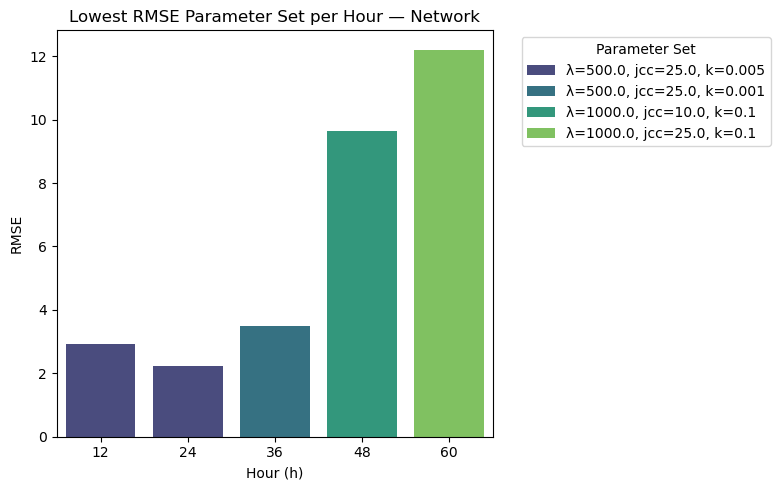

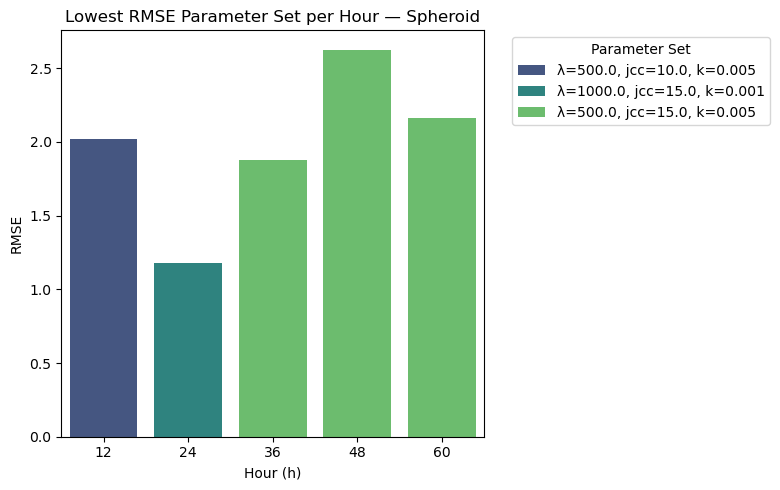

In [47]:
def plot_lowest_rmse_per_hour(sse_df, label):
    # Find the lowest RMSE entry for each hour
    best_rmse = (
        sse_df.sort_values('RMSE')
        .groupby('hour')
        .first()
        .reset_index()
    )

    # Create a compact label for each parameter set
    best_rmse['param_set'] = best_rmse.apply(
        lambda r: f"λ={r['lambda']}, jcc={r['jcc']}, k={r['k']}", axis=1
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=best_rmse,
        x="hour",
        y="RMSE",
        hue="param_set",
        dodge=False,
        palette="viridis"
    )
    plt.title(f"Lowest RMSE Parameter Set per Hour — {label.capitalize()}")
    plt.xlabel("Hour (h)")
    plt.ylabel("RMSE")
    plt.legend(title="Parameter Set", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example:
plot_lowest_rmse_per_hour(sse_network, "network")
plot_lowest_rmse_per_hour(sse_spheroid, "spheroid")


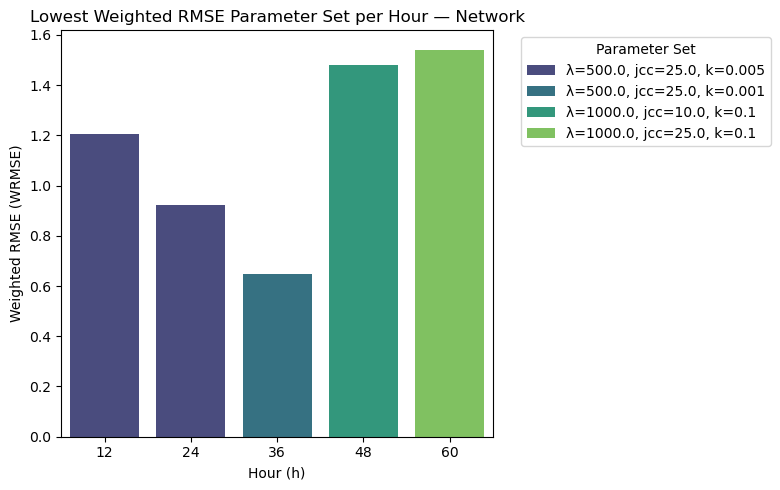

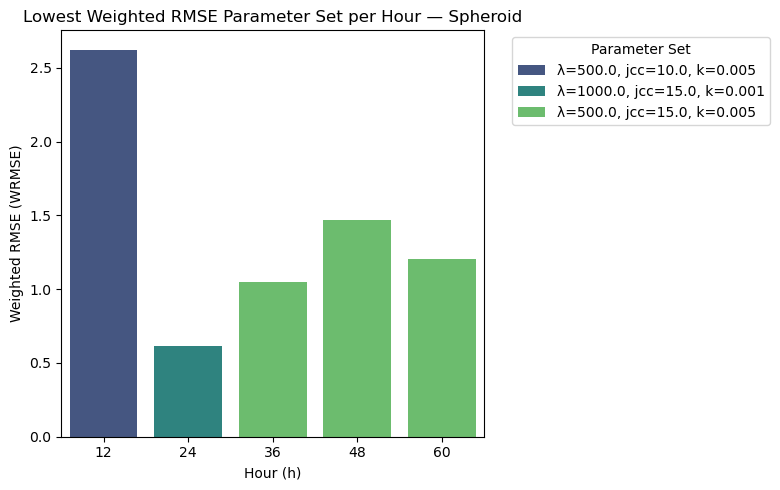

In [48]:
def plot_lowest_wrmse_per_hour(sse_df, label):
    """
    Plots the lowest WRMSE parameter set per hour for a given condition (network/spheroid).
    """
    # Ensure WRMSE exists
    if 'WRMSE' not in sse_df.columns:
        raise ValueError("DataFrame must contain a column named 'WRMSE'.")

    # Get lowest WRMSE per hour
    best_wrmse = (
        sse_df.sort_values('WRMSE')
        .groupby('hour', as_index=False)
        .first()
    )

    # Create label for parameter combinations
    best_wrmse['param_set'] = best_wrmse.apply(
        lambda r: f"λ={r['lambda']}, jcc={r['jcc']}, k={r['k']}", axis=1
    )

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=best_wrmse,
        x="hour",
        y="WRMSE",
        hue="param_set",
        dodge=False,
        palette="viridis"
    )

    plt.title(f"Lowest Weighted RMSE Parameter Set per Hour — {label.capitalize()}")
    plt.xlabel("Hour (h)")
    plt.ylabel("Weighted RMSE (WRMSE)")
    plt.legend(title="Parameter Set", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
plot_lowest_wrmse_per_hour(sse_net_combined, "network")
plot_lowest_wrmse_per_hour(sse_sph_combined, "spheroid")


In [99]:
min_wrmse = sse_net_combined["WRMSE"].min()
sse_net_combined[sse_net_combined["WRMSE"] == min_wrmse]

,cell_label,lambda,jcc,k,hour,SSE,MSE,RMSE,WSSE,WMSE,WRMSE
62,network,500.0,25.0,0.001,36,241.755924,12.087796,3.476751,8.383561,0.419178,0.64744


In [101]:
min_wrmse = sse_sph_combined["WRMSE"].min()
sse_sph_combined[sse_sph_combined["WRMSE"] == min_wrmse]

,cell_label,lambda,jcc,k,hour,SSE,MSE,RMSE,WSSE,WMSE,WRMSE
121,spheroid,1000.0,15.0,0.001,24,27.783272,1.389164,1.178628,7.536695,0.376835,0.613869


This is Aneesh parameters that minimizes the weighted RMSE, but seems not to be calculated properly

# Temitope started implementation

#### Compute sse for each time point

In [49]:
# Compute sse by replicate for sum over the sum of the targets hours
def compute_sse_by_replicate(
    residual_df: pd.DataFrame,
    target_hours=(12, 24, 36, 48, 60),
    phenotype: str | None = None,            # e.g., "network" or "spheroid"
    phenotype_col: str = "phenotype",        # set to the column that holds phenotype if present
    group_params=("cell_label", "lambda", "jcc", "k", "replicate"),
    residual_col: str = "residual",
    error_col: str = "Error",
    use_weights: bool = True
) -> pd.DataFrame:
    """
    Compute weighted Sum of Squared Error (SSE) at specific hours for each replicate.

    Parameters
    ----------
    residual_df : pd.DataFrame
        Must contain columns for grouping (default: cell_label, lambda, jcc, k, replicate),
        'hour', residual_col (default 'residual'), and optionally error_col (default 'Error').
        
        If `use_weights=True`, weight = 1 / Error^2 is used.
        
        If `phenotype` is provided and `phenotype_col` exists, rows are filtered accordingly.
    target_hours : iterable of int
        Hours to include in the SSE (default: 12, 24, 36, 48, 60).
    phenotype : str | None
        If provided, filter on this phenotype value (e.g., "network" or "spheroid").
    phenotype_col : str
        Column name that stores phenotype labels (only used if present in residual_df).
    group_params : tuple[str]
        Columns to group by when summing SSE (per replicate).
    residual_col : str
        Column name for residuals.
    error_col : str
        Column name for experimental error (used to compute weights).
    use_weights : bool
        If True and error_col exists, use weight = 1 / Error^2; otherwise use weight = 1.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: [*group_params, 'SSE', 'n_hours_used'] sorted by group_params.
    """

    df = residual_df.copy()

    # Optional phenotype filter (only if column exists and phenotype provided)
    if phenotype is not None and phenotype_col in df.columns:
        df = df[df[phenotype_col] == phenotype]

    # Aggregate to per-hour stats (mean residual; first Error for weight)
    agg_cols = list(group_params) + ["hour"]
    if error_col in df.columns:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean", error_col: "first"})
        )
    else:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean"})
        )
        # Ensure error column exists if weights are requested but missing
        if use_weights:
            # No error column; fall back to unweighted
            use_weights = False

    # Compute weight
    if use_weights:
        # Guard against zeros/NaNs in Error
        safe_err = df_agg[error_col].replace(0, np.nan)
        df_agg["weight"] = 1.0 / (safe_err ** 2)
        df_agg["weight"] = df_agg["weight"].fillna(0.0)
    else:
        df_agg["weight"] = 1.0

    # Filter target hours
    df_agg = df_agg[df_agg["hour"].isin(target_hours)].copy()

    # Weighted squared error at each hour
    df_agg["squared_error"] = (df_agg[residual_col] ** 2) * df_agg["weight"]

    # Sum SSE per group (per replicate)
    sse_df = (
        df_agg.groupby(list(group_params), as_index=False)
              .agg(SSE=("squared_error", "sum"),
                   n_hours_used=("hour", "nunique")) # number of hours used
              .sort_values(list(group_params))
              .reset_index(drop=True)
    )

    return sse_df

In [50]:
# Example for spheroid dataframe (no phenotype column present)
sse_sph = compute_sse_by_replicate(residual_sph, phenotype=None)

# Example for network dataframe (same schema)
sse_net = compute_sse_by_replicate(residual_net, phenotype=None)

# # If your dataframe has a 'phenotype' column with values "network"/"spheroid":
# sse_sph = compute_sse_by_replicate(residual_all, phenotype="spheroid", phenotype_col="phenotype")
# sse_net = compute_sse_by_replicate(residual_all, phenotype="network", phenotype_col="phenotype")

In [51]:
#residual_sph_avg
sse_sph = compute_sse_by_replicate(residual_sph_avg, phenotype=None)
sse_sph.head(5)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used
0,spheroid,500.0,1.0,0.001,1,22.383877,5
1,spheroid,500.0,1.0,0.001,2,41.431943,5
2,spheroid,500.0,1.0,0.001,3,23.882866,5
3,spheroid,500.0,1.0,0.001,4,29.043759,5
4,spheroid,500.0,1.0,0.001,5,9.247589,5


In [52]:
sse_net.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used
0,network,500.0,1.0,0.001,1,12.549602,5
1,network,500.0,1.0,0.001,2,42.725942,5
2,network,500.0,1.0,0.001,3,41.099891,5
3,network,500.0,1.0,0.001,4,17.733807,5
4,network,500.0,1.0,0.001,5,31.062705,5
5,network,500.0,1.0,0.001,6,32.157435,5
6,network,500.0,1.0,0.001,7,43.109186,5
7,network,500.0,1.0,0.001,8,46.410551,5
8,network,500.0,1.0,0.001,9,11.145786,5
9,network,500.0,1.0,0.001,10,16.947664,5


In [53]:
sse_sph.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used
0,spheroid,500.0,1.0,0.001,1,22.383877,5
1,spheroid,500.0,1.0,0.001,2,41.431943,5
2,spheroid,500.0,1.0,0.001,3,23.882866,5
3,spheroid,500.0,1.0,0.001,4,29.043759,5
4,spheroid,500.0,1.0,0.001,5,9.247589,5
5,spheroid,500.0,1.0,0.001,6,17.551275,5
6,spheroid,500.0,1.0,0.001,7,6.024802,5
7,spheroid,500.0,1.0,0.001,8,9.560093,5
8,spheroid,500.0,1.0,0.001,9,0.621019,5
9,spheroid,500.0,1.0,0.001,10,44.797221,5


In [54]:
# SSE , MSE, RMSE
def compute_sse_mse_rmse(
    residual_df: pd.DataFrame,
    target_hours=(12, 24, 36, 48, 60),
    phenotype: str | None = None,
    phenotype_col: str = "phenotype",
    group_params=("cell_label", "lambda", "jcc", "k", "replicate"),
    residual_col: str = "residual",
    error_col: str = "Error",
    use_weights: bool = True
) -> pd.DataFrame:
    """
    Compute weighted SSE, MSE, and RMSE at specific hours for each replicate.

    Parameters
    ----------
    residual_df : pd.DataFrame
        DataFrame with columns: residual, Error, hour, replicate, etc.
    target_hours : iterable of int
        Hours to include in the error calculation (default: 12, 24, 36, 48, 60).
    phenotype : str | None
        If provided and phenotype_col exists, filter data for this phenotype.
    phenotype_col : str
        Column name that identifies phenotype type (optional).
    group_params : tuple[str]
        Columns to group by (default includes replicate and key params).
    residual_col : str
        Column name for residuals.
    error_col : str
        Column name for experimental error (used for weights if enabled).
    use_weights : bool
        Whether to apply weights = 1 / Error².

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        [*group_params, n_hours_used, SSE, MSE, RMSE]
    """

    df = residual_df.copy()

    # Filter by phenotype if applicable
    if phenotype is not None and phenotype_col in df.columns:
        df = df[df[phenotype_col] == phenotype]

    # Aggregate by hour to smooth replicates
    agg_cols = list(group_params) + ["hour"]
    if error_col in df.columns:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean", error_col: "first"})
        )
    else:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean"})
        )
        if use_weights:
            use_weights = False

    # Calculate weights
    if use_weights:
        safe_err = df_agg[error_col].replace(0, np.nan)
        df_agg["weight"] = 1.0 / (safe_err ** 2)
        df_agg["weight"] = df_agg["weight"].fillna(0.0)
    else:
        df_agg["weight"] = 1.0

    # Filter only target hours
    df_agg = df_agg[df_agg["hour"].isin(target_hours)].copy()

    # Compute weighted squared error
    df_agg["squared_error"] = (df_agg[residual_col] ** 2) * df_agg["weight"]

    # Group and compute SSE, MSE, RMSE
    result = (
        df_agg.groupby(list(group_params), as_index=False)
              .agg(
                  SSE=("squared_error", "sum"),
                  n_hours_used=("hour", "nunique")
              )
    )

    # Compute MSE and RMSE
    result["MSE"] = result["SSE"] / result["n_hours_used"]
    result["RMSE"] = np.sqrt(result["MSE"])

    # Sort results
    result = result.sort_values(list(group_params)).reset_index(drop=True)

    return result

In [55]:
# For spheroid data
mse_sph = compute_sse_mse_rmse(residual_sph, phenotype=None)

# For network data
mse_net = compute_sse_mse_rmse(residual_net, phenotype=None)

# # If we have a single combined dataframe with a 'phenotype' column:
# mse_sph = compute_sse_mse_rmse(residual_all, phenotype="spheroid")
# mse_net = compute_sse_mse_rmse(residual_all, phenotype="network")

In [56]:
mse_sph.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used,MSE,RMSE
0,spheroid,500.0,1.0,0.001,1,22.383877,5,4.476775,2.115839
1,spheroid,500.0,1.0,0.001,2,41.431943,5,8.286389,2.878609
2,spheroid,500.0,1.0,0.001,3,23.882866,5,4.776573,2.185537
3,spheroid,500.0,1.0,0.001,4,29.043759,5,5.808752,2.410135
4,spheroid,500.0,1.0,0.001,5,9.247589,5,1.849518,1.359970
5,spheroid,500.0,1.0,0.001,6,17.551275,5,3.510255,1.873567
6,spheroid,500.0,1.0,0.001,7,6.024802,5,1.204960,1.097707
7,spheroid,500.0,1.0,0.001,8,9.560093,5,1.912019,1.382758
8,spheroid,500.0,1.0,0.001,9,0.621019,5,0.124204,0.352426
9,spheroid,500.0,1.0,0.001,10,44.797221,5,8.959444,2.993233


In [57]:
mse_net.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used,MSE,RMSE
0,network,500.0,1.0,0.001,1,12.549602,5,2.509920,1.584273
1,network,500.0,1.0,0.001,2,42.725942,5,8.545188,2.923215
2,network,500.0,1.0,0.001,3,41.099891,5,8.219978,2.867050
3,network,500.0,1.0,0.001,4,17.733807,5,3.546761,1.883285
4,network,500.0,1.0,0.001,5,31.062705,5,6.212541,2.492497
5,network,500.0,1.0,0.001,6,32.157435,5,6.431487,2.536038
6,network,500.0,1.0,0.001,7,43.109186,5,8.621837,2.936297
7,network,500.0,1.0,0.001,8,46.410551,5,9.282110,3.046656
8,network,500.0,1.0,0.001,9,11.145786,5,2.229157,1.493036
9,network,500.0,1.0,0.001,10,16.947664,5,3.389533,1.841068


#### Computing weighted sse, mse, rmse

In [58]:
def compute_sse_mse_rmse_weighted_by_replicates(
    residual_df: pd.DataFrame,
    target_hours=(12, 24, 36, 48, 60),
    phenotype: str | None = None,
    phenotype_col: str = "phenotype",
    group_params=("cell_label", "lambda", "jcc", "k", "replicate"),
    residual_col: str = "residual",
    error_col: str = "Error",
    use_weights: bool = True
) -> pd.DataFrame:
    """
    Compute SSE and weighted RMSE per replicate/timepoints, then aggregate to
    weighted_RMSE per parameter combo using:
        weighted_RMSE = sqrt( sum(weight * residual^2) / n_reps )

    Also returns n_hours_used (per-replicate coverage) and n_reps (per param combo).

    Returns columns:
      [*group_params, n_hours_used, SSE, n_reps, weighted_MSE_by_reps, weighted_RMSE]
    """

    df = residual_df.copy()

    # Optional phenotype filter
    if phenotype is not None and phenotype_col in df.columns:
        df = df[df[phenotype_col] == phenotype]

    # Keep only requested hours
    df = df[df["hour"].isin(target_hours)].copy()

    # Aggregate by hour within replicate/params
    agg_cols = list(group_params) + ["hour"]
    if error_col in df.columns:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean", error_col: "first"})
        )
    else:
        df_agg = (
            df.groupby(agg_cols, as_index=False)
              .agg({residual_col: "mean"})
        )
        if use_weights:
            use_weights = False  # fall back to unweighted if no Error column

    # Weights = 1 / Error^2 (safe)
    if use_weights:
        safe_err = df_agg[error_col].replace(0, np.nan)
        df_agg["weight"] = (1.0 / (safe_err ** 2)).fillna(0.0)
    else:
        df_agg["weight"] = 1.0

    # Weighted squared error at each hour
    df_agg["squared_error"] = (df_agg[residual_col] ** 2) * df_agg["weight"]

    # Sum SSE per replicate (within param combo); also track hours used
    per_rep = (
        df_agg.groupby(list(group_params), as_index=False)
              .agg(SSE=("squared_error", "sum"),
                   n_hours_used=("hour", "nunique"))
    )

    # Count number of replicates per parameter combo (excluding 'replicate')
    param_only = [c for c in group_params if c != "replicate"]
    n_reps = (
        df_agg.drop_duplicates(param_only + ["replicate"])
              .groupby(param_only, as_index=False)["replicate"].nunique()
              .rename(columns={"replicate": "n_reps"})
    )

    # Merge n_reps back to per-replicate results (on param-only keys)
    result = per_rep.merge(n_reps, on=param_only, how="left")

    # Compute weighted RMSE with denominator = number of replicates at that param
    # (same weighted SSE for each replicate's param combo; denominator shared per combo)
    # If you instead want to collapse replicates first, you could sum SSE across replicates by param_only.
    result["weighted_MSE_by_reps"] = result["SSE"] / result["n_reps"].replace(0, np.nan)
    result["weighted_RMSE"] = np.sqrt(result["weighted_MSE_by_reps"])

    # Sort for readability
    result = result.sort_values(list(group_params)).reset_index(drop=True)
    return result

In [59]:
wrsme_net = compute_sse_mse_rmse_weighted_by_replicates(residual_net)
wrsme_net.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used,n_reps,weighted_MSE_by_reps,weighted_RMSE
0,network,500.0,1.0,0.001,1,12.549602,5,20,0.627480,0.792136
1,network,500.0,1.0,0.001,2,42.725942,5,20,2.136297,1.461608
2,network,500.0,1.0,0.001,3,41.099891,5,20,2.054995,1.433525
3,network,500.0,1.0,0.001,4,17.733807,5,20,0.886690,0.941642
4,network,500.0,1.0,0.001,5,31.062705,5,20,1.553135,1.246248
5,network,500.0,1.0,0.001,6,32.157435,5,20,1.607872,1.268019
6,network,500.0,1.0,0.001,7,43.109186,5,20,2.155459,1.468148
7,network,500.0,1.0,0.001,8,46.410551,5,20,2.320528,1.523328
8,network,500.0,1.0,0.001,9,11.145786,5,20,0.557289,0.746518
9,network,500.0,1.0,0.001,10,16.947664,5,20,0.847383,0.920534


In [60]:
wrsme_sph = compute_sse_mse_rmse_weighted_by_replicates(residual_sph)
wrsme_sph.head(25)

,cell_label,lambda,jcc,k,replicate,SSE,n_hours_used,n_reps,weighted_MSE_by_reps,weighted_RMSE
0,spheroid,500.0,1.0,0.001,1,22.383877,5,20,1.119194,1.057920
1,spheroid,500.0,1.0,0.001,2,41.431943,5,20,2.071597,1.439304
2,spheroid,500.0,1.0,0.001,3,23.882866,5,20,1.194143,1.092769
3,spheroid,500.0,1.0,0.001,4,29.043759,5,20,1.452188,1.205068
4,spheroid,500.0,1.0,0.001,5,9.247589,5,20,0.462379,0.679985
5,spheroid,500.0,1.0,0.001,6,17.551275,5,20,0.877564,0.936784
6,spheroid,500.0,1.0,0.001,7,6.024802,5,20,0.301240,0.548853
7,spheroid,500.0,1.0,0.001,8,9.560093,5,20,0.478005,0.691379
8,spheroid,500.0,1.0,0.001,9,0.621019,5,20,0.031051,0.176213
9,spheroid,500.0,1.0,0.001,10,44.797221,5,20,2.239861,1.496617


In [61]:
len(wrsme_sph)

640

##### Averaging over replicates

In [62]:
def average_over_replicates(df: pd.DataFrame,
                            group_params=("cell_label", "lambda", "jcc", "k"),
                            #metrics=("SSE", "MSE", "RMSE")) -> pd.DataFrame:
                            metrics=("SSE", "weighted_MSE_by_reps", "weighted_RMSE")) -> pd.DataFrame:
    """
    Average specified metric columns across replicates for each unique parameter combination.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with columns including group_params, 'replicate', and metrics.
    group_params : tuple[str]
        Columns that define a unique parameter combination (excluding 'replicate').
    metrics : tuple[str]
        Metric columns to average (default: SSE, MSE, RMSE).

    Returns
    -------
    pd.DataFrame
        Aggregated DataFrame with mean metrics across replicates.
    """
    # Check that the columns exist
    missing_cols = [col for col in list(group_params) + list(metrics) + ["replicate"] if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in DataFrame: {missing_cols}")

    # Group by the unique parameter combination and average the metrics
    df_avg = (
        df.groupby(list(group_params), as_index=False)
          .agg({metric: "mean" for metric in metrics})
    )

    return df_avg

In [63]:
# Suppose `results_df` is the output of compute_sse_mse_rmse()
sph_avg_results = average_over_replicates(wrsme_sph)
print(sph_avg_results.head())

  cell_label  lambda   jcc      k         SSE  weighted_MSE_by_reps  weighted_RMSE
0   spheroid   500.0   1.0  0.001   20.762698              1.038135       0.935506
1   spheroid   500.0   1.0  0.005   33.402978              1.670149       1.178662
2   spheroid   500.0   1.0  0.050   45.881010              2.294051       1.348699
3   spheroid   500.0   1.0  0.100  271.483430             13.574171       2.928957
4   spheroid   500.0  10.0  0.001   27.094825              1.354741       1.102936


In [64]:
# Suppose `results_df` is the output of compute_sse_mse_rmse()
net_avg_results = average_over_replicates(wrsme_net)
print(net_avg_results.head())

  cell_label  lambda   jcc      k        SSE  weighted_MSE_by_reps  weighted_RMSE
0    network   500.0   1.0  0.001  29.829791              1.491490       1.190913
1    network   500.0   1.0  0.005  31.139299              1.556965       1.229066
2    network   500.0   1.0  0.050  35.783515              1.789176       1.200454
3    network   500.0   1.0  0.100  47.761835              2.388092       1.403266
4    network   500.0  10.0  0.001  32.890702              1.644535       1.251539


In [65]:
len(net_avg_results), len(sph_avg_results)

(32, 32)

#### Best rmse and weighted rmse

In [66]:
def _ensure_rmse(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures an 'RMSE' column exists. If missing, computes RMSE = sqrt(weighted_MSE_by_reps).
    Returns a copy.
    """
    out = df.copy()
    if 'RMSE' not in out.columns:
        if 'weighted_MSE_by_reps' not in out.columns:
            raise ValueError("Need either 'RMSE' or 'weighted_MSE_by_reps' to compute RMSE.")
        out['RMSE'] = np.sqrt(out['weighted_MSE_by_reps'])
    return out

def plot_best_rmse(
    df: pd.DataFrame,
    group_cols=("cell_label", "lambda"),
    param_cols=("jcc", "k"),
    rmse_col="RMSE",
    show_n=10,
    annotate_params=True
):
    """
    Finds the best (lowest) RMSE per (cell_label, lambda) and plots a bar chart summary.
    Also returns a DataFrame of the 'winners' with their parameter settings.

    Parameters
    ----------
    df : DataFrame with columns: group_cols + param_cols + rmse_col (or weighted_MSE_by_reps)
    group_cols : tuple[str]
        Columns defining a 'slice' (e.g., phenotype & lambda).
    param_cols : tuple[str]
        Parameter columns (expected: ('jcc', 'k')).
    rmse_col : str
        Column name for RMSE; computed from weighted_MSE_by_reps if missing.
    show_n : int
        Max number of bars to show (sorted by RMSE ascending); useful if many groups.
    annotate_params : bool
        Annotate each bar with the winning (jcc, k).

    Returns
    -------
    winners : pd.DataFrame
        One row per group with best RMSE and its parameters.
    fig, ax : Matplotlib figure and axes.
    """
    df2 = _ensure_rmse(df)
    cols_needed = set(group_cols + param_cols + (rmse_col,))
    missing = cols_needed - set(df2.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Pick the argmin row per group
    winners_idx = df2.groupby(list(group_cols))[rmse_col].idxmin()
    winners = df2.loc[winners_idx].sort_values(rmse_col, ascending=True).reset_index(drop=True)

    # Build display index like "network | λ=500"
    winners['_group_display'] = winners.apply(
        lambda r: f"{r[group_cols[0]]} | λ={r[group_cols[1]]}", axis=1
    )

    # If there are many groups, just show top-N lowest RMSE
    winners_show = winners.head(show_n)

    fig, ax = plt.subplots(figsize=(min(12, 1.2 * len(winners_show) + 4), 5))
    bars = ax.bar(winners_show['_group_display'], winners_show[rmse_col])
    ax.set_ylabel(rmse_col)
    ax.set_title("Best (lowest) RMSE per (cell_label, λ)")
    ax.set_xticklabels(winners_show['_group_display'], rotation=45, ha='right')

    if annotate_params:
        for b, (_, row) in zip(bars, winners_show.iterrows()):
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height(),
                f"jcc={row[param_cols[0]]}, k={row[param_cols[1]]}",
                ha='center', va='bottom', fontsize=9
            )

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    fig.tight_layout()
    return winners, fig, ax


def plot_wrmse_heatmaps(
    df: pd.DataFrame,
    wrmse_col="weighted_RMSE",
    group_cols=("cell_label", "lambda"),
    param_rows="jcc",
    param_cols="k",
    cmap="viridis",
    annotate_values=False,
    mark_min=True
):
    """
    For each (cell_label, λ) slice, plot a heatmap of weighted_RMSE over the jcc × k grid.

    Parameters
    ----------
    df : DataFrame with columns: group_cols + [param_rows, param_cols, wrmse_col]
    wrmse_col : str
        Column name for weighted RMSE.
    group_cols : tuple[str]
        Columns defining a 'slice' (e.g., phenotype & lambda).
    param_rows : str
        Parameter to place on heatmap rows (e.g., 'jcc').
    param_cols : str
        Parameter to place on heatmap columns (e.g., 'k').
    cmap : str
        Seaborn/Matplotlib colormap.
    annotate_values : bool
        If True, annotate each cell with its numeric value.
    mark_min : bool
        If True, highlight the cell with the lowest WRMSE per slice.

    Returns
    -------
    fig, axes, pivots : (Figure, list[Axes], dict)
        'pivots' maps each slice key to its pivoted DataFrame used for the heatmap.
    """
    required = set(group_cols + (param_rows, param_cols, wrmse_col))
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    slices = df.groupby(list(group_cols))
    n = len(slices)
    ncols = min(3, n) or 1
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5.5 * ncols, 4.8 * nrows),
        squeeze=False
    )

    pivots = {}
    for ax, (key, g) in zip(axes.flatten(), slices):
        # Pivot: rows=jcc, cols=k
        pivot = g.pivot_table(index=param_rows, columns=param_cols, values=wrmse_col, aggfunc='mean')
        pivots[key] = pivot

        sns.heatmap(
            pivot, ax=ax, cmap=cmap, annot=annotate_values,
            fmt=".3f" if annotate_values else "",
            cbar=True
        )
        # Title like: "network | λ=500"
        title = f"{key[0]} | λ={key[1]}" if len(group_cols) == 2 else " | ".join(map(str, key))
        ax.set_title(f"WRMSE over {param_rows} × {param_cols}\n{title}")
        ax.set_xlabel(param_cols)
        ax.set_ylabel(param_rows)

        if mark_min and not pivot.empty:
            # find min coordinate in the heatmap grid
            min_pos = np.unravel_index(np.nanargmin(pivot.values), pivot.shape)
            y, x = min_pos  # row, col indices
            ax.scatter(x + 0.5, y + 0.5, s=120, marker="*", edgecolors="black", linewidths=0.8)

    # Hide any unused axes if slices < nrows*ncols
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes.flatten()[:n], pivots

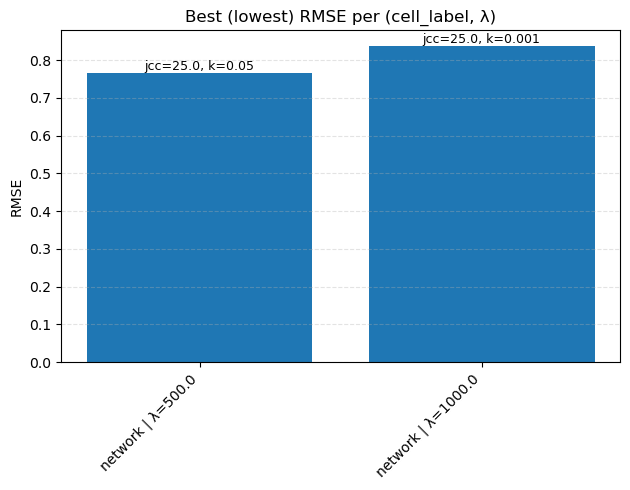

In [67]:
# Example DataFrame 'df' with your columns:
# ['cell_label','lambda','jcc','k','SSE','weighted_MSE_by_reps','weighted_RMSE']

# 1) Best (lowest) RMSE summary (RMSE = sqrt(weighted_MSE_by_reps) if not present)
winners, fig1, ax1 = plot_best_rmse(net_avg_results)

# Save the plot
plt.savefig('bestRMSEnetwork.png', dpi=1000, bbox_inches='tight')

# Display the plot
plt.show()

In [68]:
winners

,cell_label,lambda,jcc,k,SSE,weighted_MSE_by_reps,weighted_RMSE,RMSE,_group_display
0,network,500.0,25.0,0.050,11.775867,0.588793,0.742288,0.767329,network | λ=500.0
1,network,1000.0,25.0,0.001,14.028336,0.701417,0.828662,0.837506,network | λ=1000.0


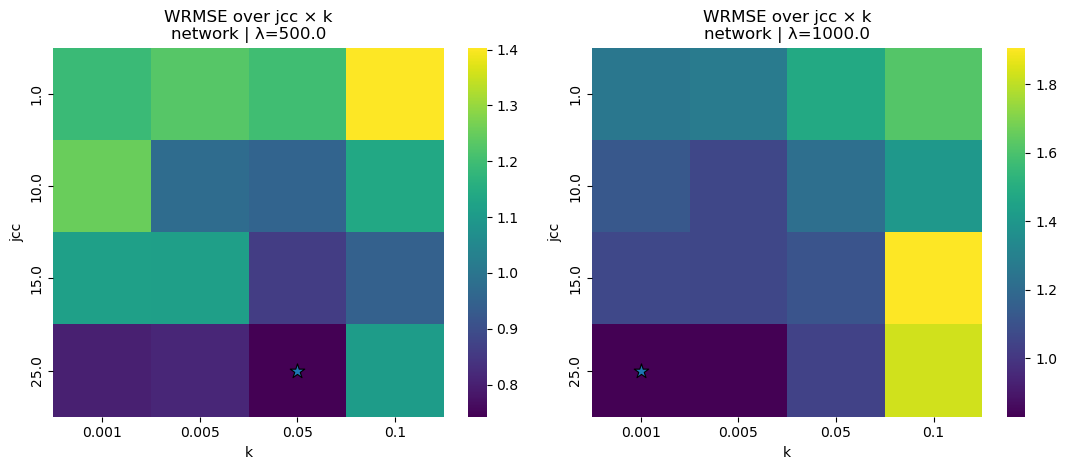

In [69]:
# 2) WRMSE heatmaps for each (cell_label, λ) slice
fig2, axes2, pivots = plot_wrmse_heatmaps(net_avg_results, wrmse_col="weighted_RMSE")
# Save the plot
plt.savefig('bestRMSEnetworkHeatmap.png', dpi=1000, bbox_inches='tight')

# Display the plot
plt.show()

##### Spheriod best

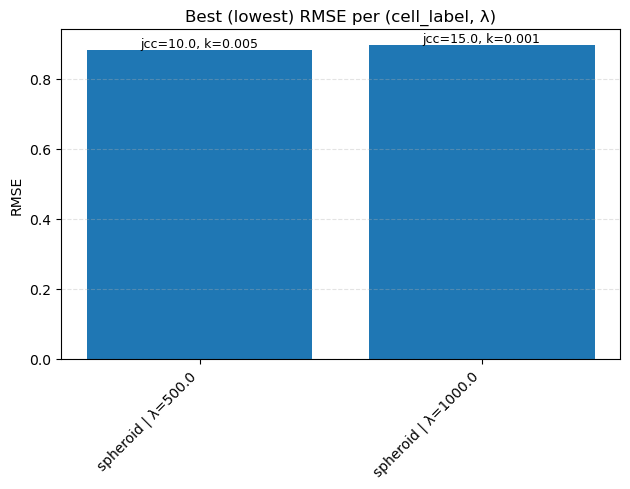

In [70]:
# 1) Best (lowest) RMSE summary (RMSE = sqrt(weighted_MSE_by_reps) if not present)
winners, fig1, ax1 = plot_best_rmse(sph_avg_results)
# Save the plot
plt.savefig('bestRMSEspheriod.png', dpi=1000, bbox_inches='tight')

# Display the plot
plt.show()

In [71]:
winners

,cell_label,lambda,jcc,k,SSE,weighted_MSE_by_reps,weighted_RMSE,RMSE,_group_display
0,spheroid,500.0,10.0,0.005,15.563940,0.778197,0.844174,0.882155,spheroid | λ=500.0
1,spheroid,1000.0,15.0,0.001,16.047867,0.802393,0.858508,0.895764,spheroid | λ=1000.0


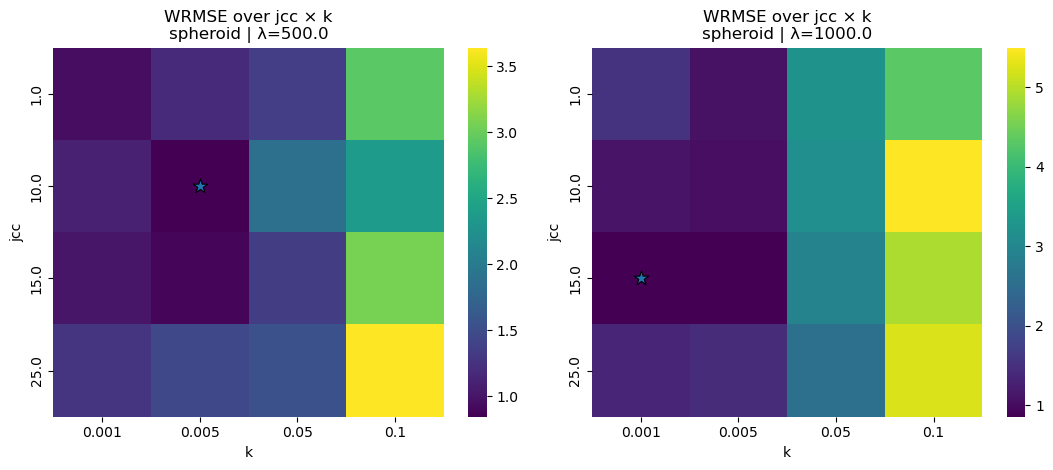

In [72]:
# 2) WRMSE heatmaps for each (cell_label, λ) slice
fig2, axes2, pivots = plot_wrmse_heatmaps(sph_avg_results, wrmse_col="weighted_RMSE")
# Save the plot
plt.savefig('bestRMSEspheriodHeatmap.png', dpi=1000, bbox_inches='tight')

# Display the plot
plt.show()

In [73]:
min_wrmse = sph_avg_results["weighted_RMSE"].min()
sph_avg_results[sph_avg_results["weighted_RMSE"] == min_wrmse]

,cell_label,lambda,jcc,k,SSE,weighted_MSE_by_reps,weighted_RMSE
5,spheroid,500.0,10.0,0.005,15.56394,0.778197,0.844174


In [74]:
min_wrmse = net_avg_results["weighted_RMSE"].min()
net_avg_results[net_avg_results["weighted_RMSE"] == min_wrmse]

,cell_label,lambda,jcc,k,SSE,weighted_MSE_by_reps,weighted_RMSE
14,network,500.0,25.0,0.05,11.775867,0.588793,0.742288


These are paramters for the that minimize the weigthed RMSE when SSE is calculated by summing the 5 time points

#### PLOT RESIDUAL

In [78]:
def plot_residuals_by_phenotype(
    net_merged, sph_merged, exp_data,
    phenotype='network',
    aggregate=True
):
    """
    Plot residual vs (time, prediction, actual experiment) for one phenotype.

    Parameters
    ----------
    net_merged : pd.DataFrame
        Must include: ['cell_id','cell_label','lambda','jcc','k','replicate','hour','dist_to_cell1', ...]
    sph_merged : pd.DataFrame
        Same columns as net_merged.
    exp_data : pd.DataFrame
        Columns: ['Condition','Hours','Invasion','Error']
    phenotype : {'network','spheroid'}
        Which phenotype to plot.
    aggregate : bool, default True
        If True, averages by hour for the time panel.

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
    """
    ph = str(phenotype).strip().lower()
    if ph not in ('network', 'spheroid'):
        raise ValueError("phenotype must be 'network' or 'spheroid'")

    sim_df = net_merged if ph == 'network' else sph_merged

    # Merge sim with matching experimental rows (case-insensitive)
    exp_filt = exp_data.loc[
        exp_data['Condition'].str.lower() == ph, ['Hours', 'Invasion', 'Error']
    ]

    merged = (
        pd.merge(sim_df, exp_filt, left_on='hour', right_on='Hours', how='inner')
          .drop(columns=['Hours'])
          .copy()
    )

    # Residual = Simulation - Experiment
    merged['residual'] = merged['dist_to_cell1'] - merged['Invasion']

    # Columns we need downstream
    cols = ['cell_id','cell_label','lambda','jcc','k','replicate',
            'hour','dist_to_cell1','Invasion','Error','residual']
    merged = merged[cols].sort_values(['hour','replicate'])

    # For the time panel: optional aggregation across replicates per hour
    if aggregate:
        plot_time = (
            merged.groupby('hour', as_index=False)
                  .agg(residual=('residual','mean'))
        )
    else:
        plot_time = merged[['hour','residual']].copy()

    # --- Plotting: residual vs time, residual vs prediction, residual vs experiment ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    # 1) residual vs TIME
    axes[0].plot(plot_time['hour'], plot_time['residual'], marker='o')
    axes[0].axhline(0, linestyle='--', linewidth=1)
    axes[0].set_xlabel('Time (hour)')
    axes[0].set_ylabel('Residual (Sim - Exp)')
    axes[0].set_title(f'{phenotype.title()}: Residual vs Time')

    # 2) residual vs PREDICTION (simulation)
    axes[1].scatter(merged['dist_to_cell1'], merged['residual'], alpha=0.6)
    axes[1].axhline(0, linestyle='--', linewidth=1)
    axes[1].set_xlabel('Prediction (Simulation: dist_to_cell1)')
    axes[1].set_ylabel('Residual (Sim - Exp)')
    axes[1].set_title(f'{phenotype.title()}: Residual vs Prediction')

    # 3) residual vs ACTUAL (experiment)
    axes[2].scatter(merged['Invasion'], merged['residual'], alpha=0.6)
    axes[2].axhline(0, linestyle='--', linewidth=1)
    axes[2].set_xlabel('Actual (Experiment: Invasion)')
    axes[2].set_ylabel('Residual (Sim - Exp)')
    axes[2].set_title(f'{phenotype.title()}: Residual vs Actual')

    return fig, axes

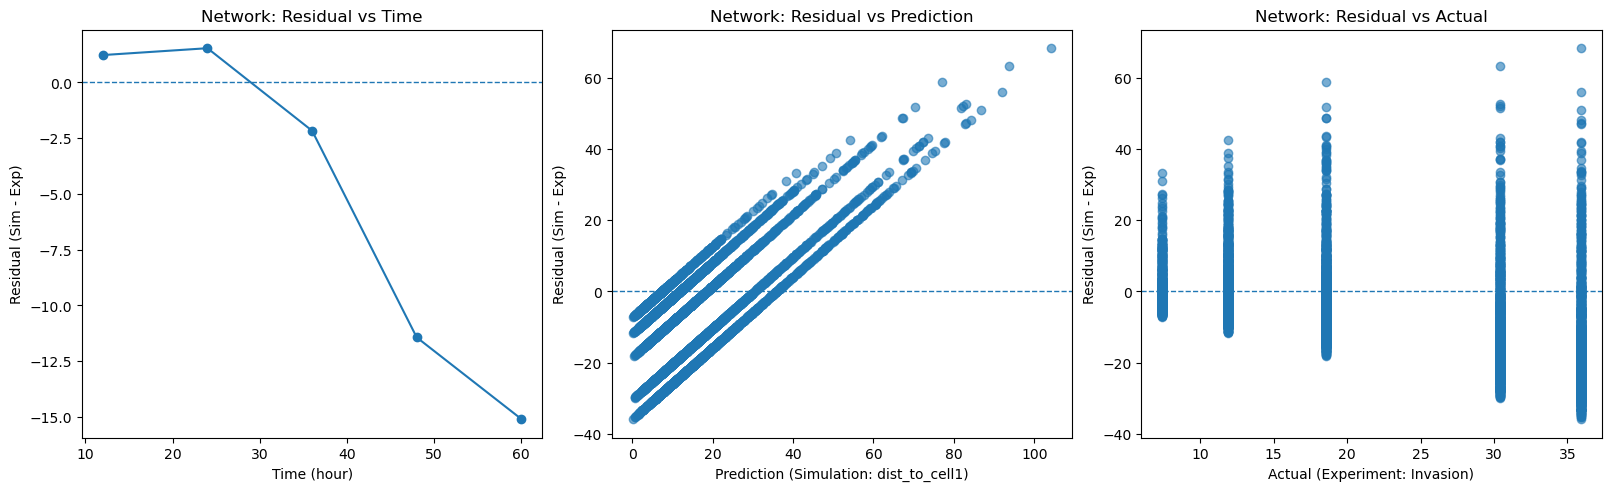

In [79]:
fig, axes = plot_residuals_by_phenotype(net_merged, sph_merged, exp_data, phenotype='network', aggregate=True)
plt.show()

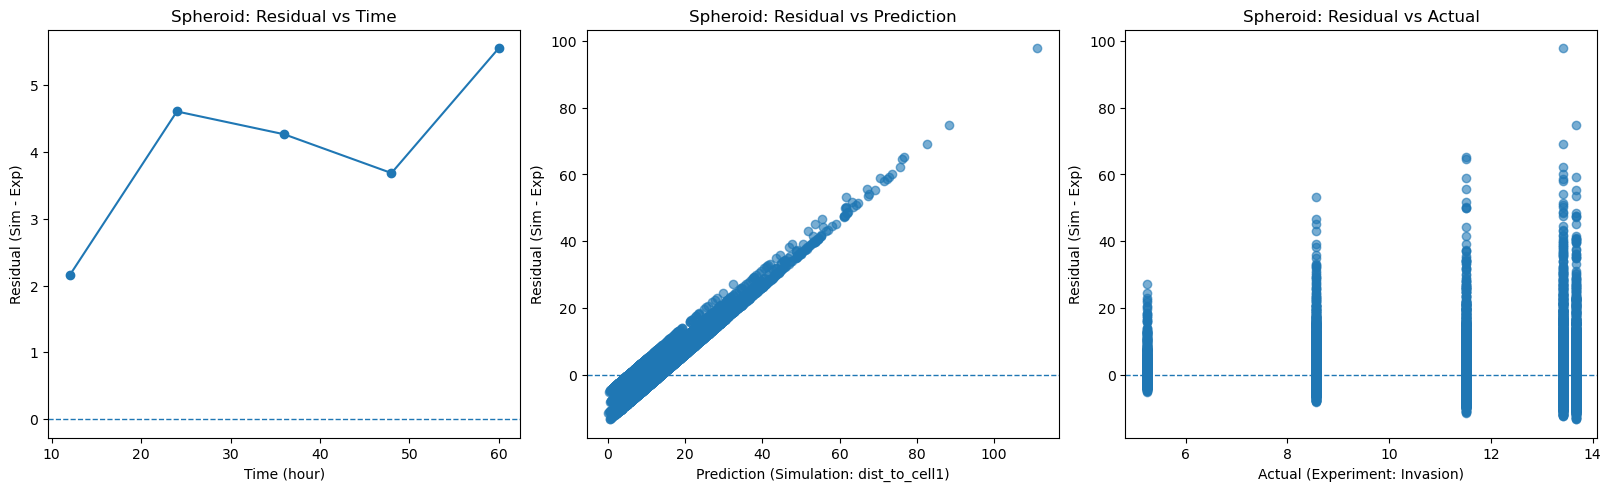

In [80]:
fig, axes = plot_residuals_by_phenotype(net_merged, sph_merged, exp_data,phenotype='spheroid', aggregate=True)
plt.show()

In [81]:
def plot_residuals_by_phenotype(
    net_merged, sph_merged, exp_data,
    phenotype='network',
    aggregate=True
):
    """
    Plot residual vs (time, prediction, actual experiment) for one phenotype.

    Parameters
    ----------
    net_merged : pd.DataFrame
        Must include: ['cell_id','cell_label','lambda','jcc','k','replicate','hour','dist_to_cell1', ...]
    sph_merged : pd.DataFrame
        Same columns as net_merged.
    exp_data : pd.DataFrame
        Columns: ['Condition','Hours','Invasion','Error']
    phenotype : {'network','spheroid'}
        Which phenotype to plot.
    aggregate : bool, default True
        If True, averages by hour for the time panel.

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
    """
    ph = str(phenotype).strip().lower()
    if ph not in ('network', 'spheroid'):
        raise ValueError("phenotype must be 'network' or 'spheroid'")

    sim_df = net_merged if ph == 'network' else sph_merged

    # Merge sim with experimental data
    exp_filt = exp_data.loc[
        exp_data['Condition'].str.lower() == ph, ['Hours', 'Invasion', 'Error']
    ]
    merged = (
        pd.merge(sim_df, exp_filt, left_on='hour', right_on='Hours', how='inner')
          .drop(columns=['Hours'])
          .copy()
    )

    # Compute residual = Simulation - Experiment
    merged['residual'] = merged['dist_to_cell1'] - merged['Invasion']

    cols = ['cell_id','cell_label','lambda','jcc','k','replicate',
            'hour','dist_to_cell1','Invasion','Error','residual']
    merged = merged[cols].sort_values(['hour','replicate'])

    # Aggregation for time plot (optional)
    if aggregate:
        plot_time = (
            merged.groupby('hour', as_index=False)
                  .agg(residual=('residual','mean'))
        )
    else:
        plot_time = merged[['hour','residual']].copy()

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    # (1) Residual vs TIME — scatter plot only (no connecting lines)
    if aggregate:
        axes[0].scatter(plot_time['hour'], plot_time['residual'],
                        color='tab:blue', s=60, alpha=0.8, label='Mean residual')
    else:
        # plot each replicate with different color for clarity
        for rep, rep_df in merged.groupby('replicate'):
            axes[0].scatter(rep_df['hour'], rep_df['residual'],
                            s=50, alpha=0.7, label=f'Rep {rep}')
    axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
    axes[0].set_xlabel('Time (hour)')
    axes[0].set_ylabel('Residual (Sim - Exp)')
    axes[0].set_title(f'{phenotype.title()}: Residual vs Time')
    axes[0].legend(title='Replicate', fontsize=8, loc='best')
    axes[0].grid(alpha=0.3)

    # (2) Residual vs PREDICTION
    axes[1].scatter(merged['dist_to_cell1'], merged['residual'],
                    color='tab:orange', alpha=0.7, s=50)
    axes[1].axhline(0, linestyle='--', linewidth=1, color='gray')
    axes[1].set_xlabel('Prediction (Simulation: dist_to_cell1)')
    axes[1].set_ylabel('Residual (Sim - Exp)')
    axes[1].set_title(f'{phenotype.title()}: Residual vs Prediction')
    axes[1].grid(alpha=0.3)

    # (3) Residual vs ACTUAL
    axes[2].scatter(merged['Invasion'], merged['residual'],
                    color='tab:green', alpha=0.7, s=50)
    axes[2].axhline(0, linestyle='--', linewidth=1, color='gray')
    axes[2].set_xlabel('Actual (Experiment: Invasion)')
    axes[2].set_ylabel('Residual (Sim - Exp)')
    axes[2].set_title(f'{phenotype.title()}: Residual vs Actual')
    axes[2].grid(alpha=0.3)

    return fig, axes

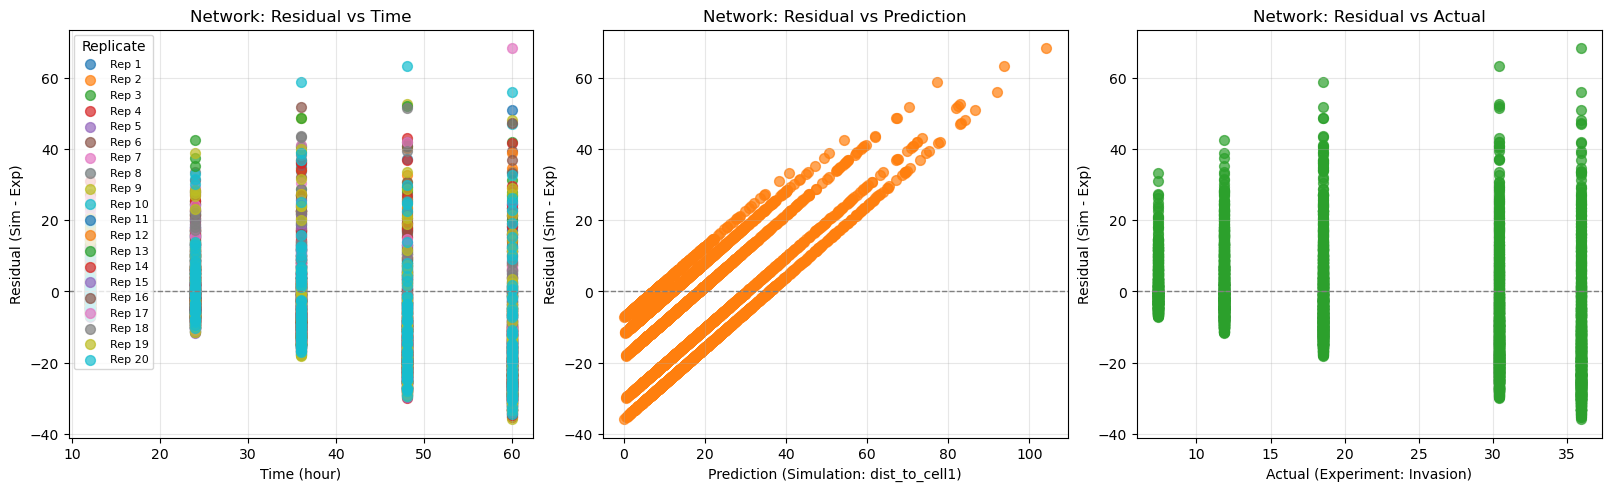

In [82]:
fig, axes = plot_residuals_by_phenotype(net_merged, sph_merged, exp_data, phenotype='network', aggregate=False)
plt.show()

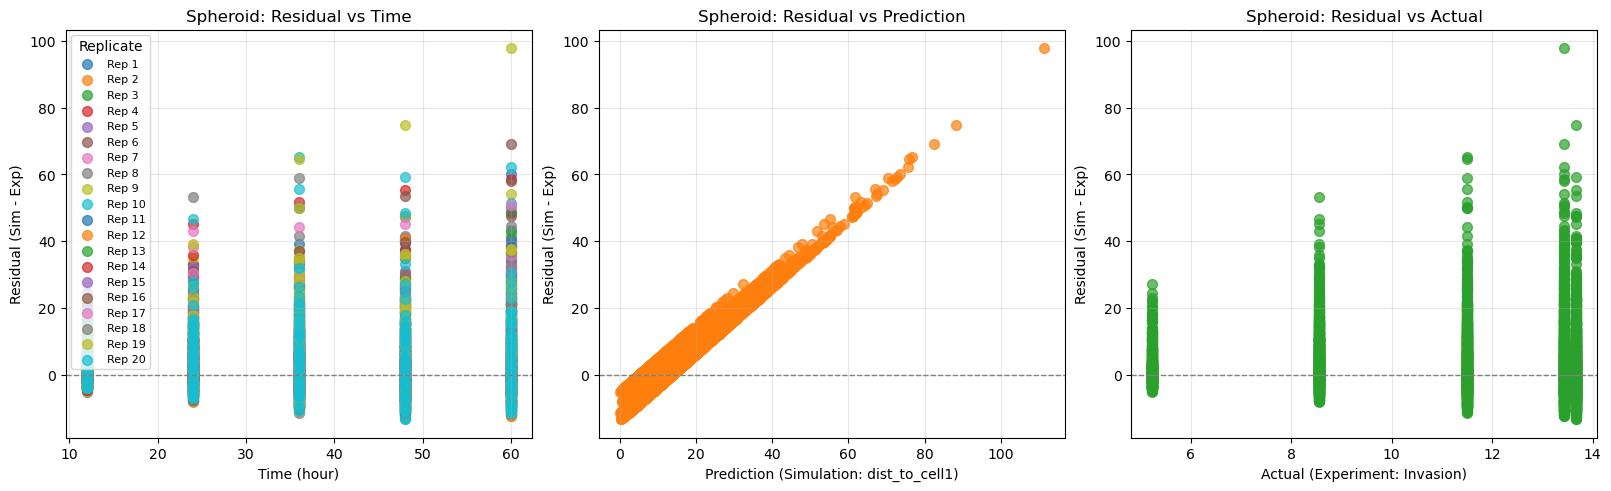

In [83]:
fig, axes = plot_residuals_by_phenotype(net_merged, sph_merged, exp_data,phenotype='spheroid', aggregate=False)
plt.show()

##### Normalize columns and extract_cells_and_refs_merged for both cell_typeposition and celldata

In [84]:
# -----------------------------
# Helpers
# -----------------------------
def _normalize_columns(df, extra_map=None):
    """Lower/strip column names and apply flexible renames."""
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    colmap = {
        # ids / step
        "cellid": "cell_id",
        "id": "cell_id",
        "step": "mcs",
        "time": "mcs",
        # positions
        "celltype": "cell_type",
        "ctype": "cell_type",
        "xpos": "x",
        "ypos": "y",
        "x_cm": "x",
        "y_cm": "y",
        "xcm": "x",
        "ycm": "y",
    }
    if extra_map:
        colmap.update(extra_map)
    return df.rename(columns=colmap)

def _ensure_required(df, required, file_path):
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"Skipping invalid file (missing {missing}): {file_path}")
        return None
    return df

# -----------------------------
# Main function (merge on MCS only)
# -----------------------------
def extract_cells_and_refs_merged(
    base_path,
    params_df,
    label="network",
    NumberOfReps=20,
    steps_per_hour=None,
    merge_how="inner",
):
    """
    Walk parameter folders and merge `cell_typeposition{rep}.csv` with `celldata{rep}.csv`
    **only on `mcs`** (NOT on `cell_id`).

    Parameters
    ----------
    base_path : str
        Root directory containing parameterized folders.
    params_df : pd.DataFrame
        Columns: ['lambda','jcc','k'] (at minimum).
    label : str
        Used by format_param_name(lam, jcc, k, label) to compose folder names.
    NumberOfReps : int
        Number of replicate pairs to process.
    steps_per_hour : dict | None
        e.g., {0:0, 24:1000, 48:2000}. If None, keep all MCS.
    merge_how : str
        Pandas merge how ('inner', 'left', ...). Default 'inner'.

    Returns
    -------
    ref_df : pd.DataFrame
        One reference row per (param set, replicate): cell_id=1 at mcs=0 if present,
        else earliest mcs for cell_id=1. Columns: ['cell_id','mcs','x','y','cell_label',
        'replicate','lambda','jcc','k'].
    all_cells_df : pd.DataFrame
        Merged rows (positions ⨝ celldata on 'mcs') with metadata.
        If steps_per_hour provided, includes 'hour'.
    """
    # Allow external formatter if already defined; otherwise use a fallback.
    try:
        _ = format_param_name  # noqa: F401
        use_external_formatter = True
    except NameError:
        use_external_formatter = False

    def _format_param_name(lam, jcc, k, label):
        if use_external_formatter:
            return format_param_name(lam, jcc, k, label)
        # Fallback: compact, filesystem-friendly tokens
        def _tok(v):
            s = str(v).replace(".", "_")
            return s.replace("-", "m")
        return f"{label}_{_tok(lam)}_{_tok(jcc)}_{_tok(k)}"

    ref_rows = []
    merged_rows = []

    for _, prow in params_df.iterrows():
        lam, jcc, k = prow["lambda"], prow["jcc"], prow["k"]
        folder_name = _format_param_name(lam, jcc, k, label)
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_name}")
            continue

        for rep in range(1, NumberOfReps + 1):
            pos_path = os.path.join(folder_path, f"cell_typeposition{rep}.csv")
            dat_path = os.path.join(folder_path, f"celldata{rep}.csv")

            if not os.path.isfile(pos_path):
                print(f"Missing file: {pos_path}")
                continue
            if not os.path.isfile(dat_path):
                print(f"Missing file: {dat_path}")
                continue

            # ---- Read & normalize (fix for low_memory/python engine issue) ----
            pos = pd.read_csv(pos_path, low_memory=False)
            data = pd.read_csv(dat_path, low_memory=False)

            pos = _normalize_columns(pos)
            data = _normalize_columns(data)

            # ---- Validate minimal schemas ----
            # Positions need at least mcs (plus x/y/cell_id if you use them)
            pos = _ensure_required(pos, {"mcs"}, pos_path)
            data = _ensure_required(data, {"mcs"}, dat_path)
            if pos is None or data is None:
                continue

            # Map numeric cell_type → label, if available; else fallback to folder label
            if "cell_type" in pos.columns:
                pos["cell_label"] = pos["cell_type"].map({1: "spheroid", 2: "network"}).fillna(pos.get("cell_type"))
            elif "cell_label" not in pos.columns:
                pos["cell_label"] = label

            # ---- (Optional) Narrow by steps_per_hour BEFORE merge to reduce explosion ----
            if steps_per_hour is not None:
                keep_steps = set(steps_per_hour.values())
                pos = pos[pos["mcs"].isin(keep_steps)]
                data = data[data["mcs"].isin(keep_steps)]

            # ---- Merge ONLY on MCS ----
            merged = pd.merge(
                pos, data,
                on=["mcs"],  # <-- key change: merge strictly on 'mcs'
                how=merge_how,
                suffixes=("_pos", "_dat")
            )

            # Attach metadata
            merged["lambda"] = lam
            merged["jcc"] = jcc
            merged["k"] = k
            merged["replicate"] = rep

            # If steps_per_hour provided, map back 'hour'
            if steps_per_hour is not None and not merged.empty:
                inv_map = {step: hr for hr, step in steps_per_hour.items()}
                merged["hour"] = merged["mcs"].map(inv_map)

            merged_rows.append(merged)

            # ---- Build reference row from POS only (cell_id==1) ----
            if "cell_id" in pos.columns:
                ref_pos = pos[pos["cell_id"] == 1].sort_values("mcs")
                if not ref_pos.empty:
                    r0 = ref_pos[ref_pos["mcs"] == 0]
                    ref_pick = r0.iloc[0] if not r0.empty else ref_pos.iloc[0]
                    ref_rows.append({
                        "cell_id": int(ref_pick["cell_id"]),
                        "mcs": int(ref_pick["mcs"]),
                        "x": ref_pick["x"] if "x" in ref_pos.columns else None,
                        "y": ref_pick["y"] if "y" in ref_pos.columns else None,
                        "cell_label": ref_pick.get("cell_label", label),
                        "replicate": rep,
                        "lambda": lam, "jcc": jcc, "k": k
                    })
                else:
                    print(f"No cell_id=1 found in {pos_path}")
            else:
                # If cell_id column doesn't exist at all, we cannot pick a reference cell
                print(f"'cell_id' not found in {pos_path}; skipping reference pick.")

    ref_df = pd.DataFrame(ref_rows)
    all_cells_df = pd.concat(merged_rows, ignore_index=True) if merged_rows else pd.DataFrame()

    # ---- Post-cleanup: enforce canonical dtypes ----
    if not all_cells_df.empty:
        for c in ["mcs", "replicate"]:
            if c in all_cells_df.columns:
                all_cells_df[c] = pd.to_numeric(all_cells_df[c], errors="coerce").astype("Int64")
        if "hour" in all_cells_df.columns:
            all_cells_df["hour"] = pd.to_numeric(all_cells_df["hour"], errors="coerce").astype("Int64")

    return ref_df, all_cells_df


In [85]:
ref_net, all_net = extract_cells_and_refs_merged(base_path, params_df, label="network",  NumberOfReps=20, steps_per_hour=steps_per_hour)
ref_sph, all_sph = extract_cells_and_refs_merged(base_path, params_df, label="spheroid",  NumberOfReps=20, steps_per_hour=steps_per_hour)

In [86]:
ref_sph.head()

,cell_id,mcs,x,y,cell_label,replicate,lambda,jcc,k
0,1,500,100.776923,99.138462,spheroid,1,500.0,1.0,0.001
1,1,500,99.465649,100.847328,spheroid,2,500.0,1.0,0.001
2,1,500,99.100775,99.689922,spheroid,3,500.0,1.0,0.001
3,1,500,100.559055,100.125984,spheroid,4,500.0,1.0,0.001
4,1,500,99.124031,101.372093,spheroid,5,500.0,1.0,0.001


In [87]:
all_sph.head()

,mcs,cell_id,cell_type,x,y,cell_label,circularity,cell_invasion,lambda,jcc,k,replicate,hour
0,500,1,1,100.776923,99.138462,spheroid,1.000000,1.638462,500.0,1.0,0.001,1,12
1,1000,1,1,101.220779,93.480519,spheroid,0.758019,9.731045,500.0,1.0,0.001,1,24
2,1000,2,1,103.040000,99.346667,spheroid,0.758019,9.731045,500.0,1.0,0.001,1,24
3,1500,1,1,105.816092,95.965517,spheroid,0.796981,9.850575,500.0,1.0,0.001,1,36
4,1500,2,1,100.166667,98.522222,spheroid,0.796981,9.850575,500.0,1.0,0.001,1,36


In [88]:
all_net.head()

,mcs,cell_id,cell_type,x,y,cell_label,circularity,cell_invasion,lambda,jcc,k,replicate,hour
0,500,1,2,100.287879,104.924242,network,1.000000,4.636364,500.0,1.0,0.001,1,12
1,1000,1,2,101.802632,105.921053,network,0.897103,4.118421,500.0,1.0,0.001,1,24
2,1000,2,2,104.805195,102.090909,network,0.897103,4.118421,500.0,1.0,0.001,1,24
3,1500,1,2,107.112360,106.842697,network,0.899001,1.003466,500.0,1.0,0.001,1,36
4,1500,2,2,107.674157,101.640449,network,0.899001,1.003466,500.0,1.0,0.001,1,36


## Heatmp for circularity and cell invasion
#### Plot heatmap of the calibrated data

In [89]:
# Plot heatmap
def plot_invasion_circularity_heatmaps(all_cells_df):
    """
    Aggregates mean circularity and cell invasion across replicates,
    pivots the data for heatmap visualization, and plots both heatmaps side by side.

    Parameters
    ----------
    all_cells_df : pd.DataFrame
        Must contain at least the following columns:
        ['jcc', 'k', 'circularity', 'cell_invasion']

    Returns
    -------
    pivot_circ : pd.DataFrame
        Pivoted mean circularity values (rows=jcc, columns=k)
    pivot_invasion : pd.DataFrame
        Pivoted mean cell invasion values (rows=jcc, columns=k)
    """

    # ----------------------------
    # Step 1: Aggregate (Mean across replicates)
    # ----------------------------
    agg_all_cells_df = all_cells_df.groupby(['jcc', 'k']).agg({
        'circularity': 'mean',
        'cell_invasion': 'mean'
    }).reset_index()

    # ----------------------------
    # Step 2: Pivot for heatmaps
    # ----------------------------
    pivot_circ = agg_all_cells_df.pivot(index='jcc', columns='k', values='circularity')
    pivot_invasion = agg_all_cells_df.pivot(index='jcc', columns='k', values='cell_invasion')

    # ----------------------------
    # Step 3: Plot heatmaps
    # ----------------------------
    plt.figure(figsize=(14, 6))

    # Circularity Heatmap
    plt.subplot(1, 2, 1)
    plt.title('Mean Circularity')
    plt.xlabel('Chemoattractant Secretion Rate (k)')
    plt.ylabel('Cell-Cell Adhesion Energy (Jcc)')
    heatmap1 = plt.imshow(pivot_circ, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(heatmap1, label='Circularity')
    plt.xticks(
        ticks=np.arange(len(pivot_circ.columns)),
        labels=np.round(pivot_circ.columns.values, 3),
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(pivot_circ.index)),
        labels=pivot_circ.index
    )

    # Invasion Heatmap
    plt.subplot(1, 2, 2)
    plt.title('Mean Cell Invasion')
    plt.xlabel('Chemoattractant Secretion Rate (k)')
    plt.ylabel('Cell-Cell Adhesion Energy (Jcc)')
    heatmap2 = plt.imshow(pivot_invasion, aspect='auto', cmap='plasma', origin='lower')
    plt.colorbar(heatmap2, label='Cell Invasion')
    plt.xticks(
        ticks=np.arange(len(pivot_invasion.columns)),
        labels=np.round(pivot_invasion.columns.values, 3),
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(pivot_invasion.index)),
        labels=pivot_invasion.index
    )

    plt.tight_layout()
    plt.show()

    return pivot_circ, pivot_invasion


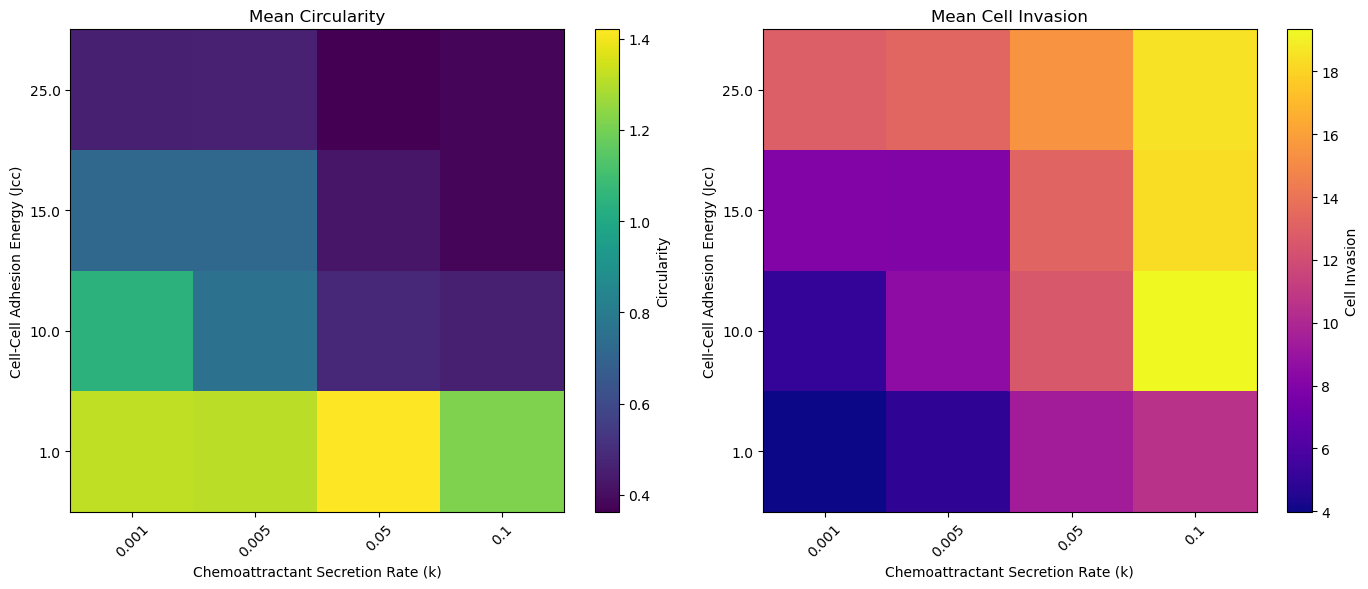

In [90]:
pivot_circ, pivot_invasion = plot_invasion_circularity_heatmaps(all_net)

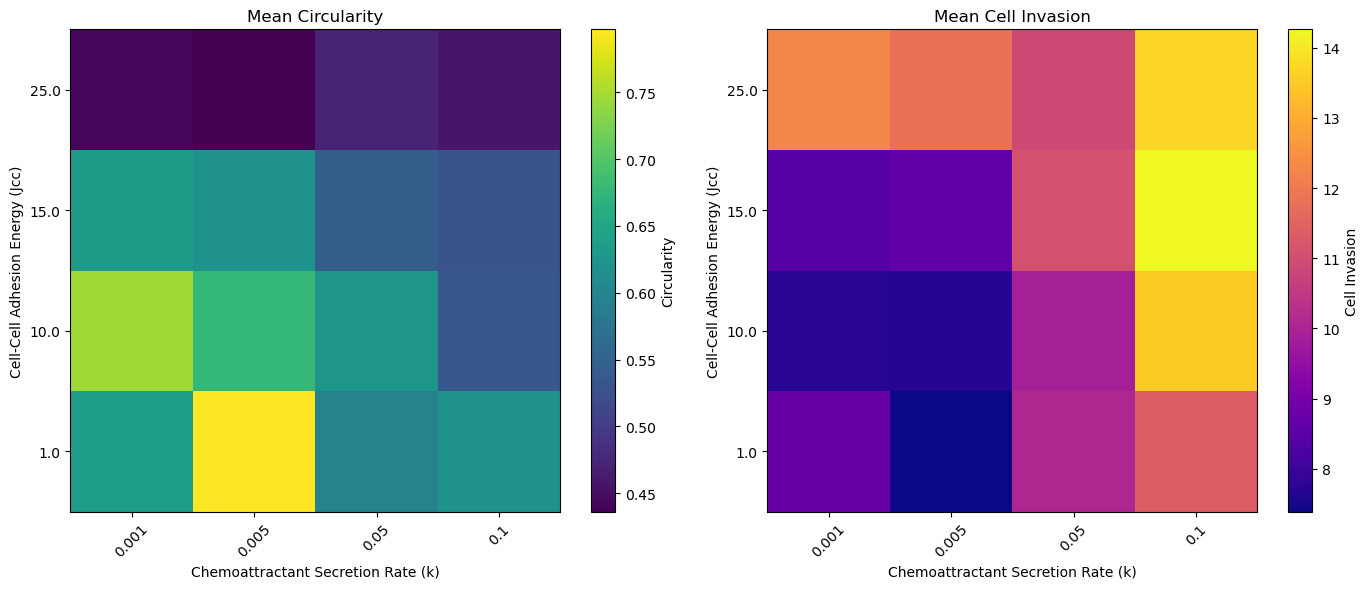

In [91]:
pivot_circ, pivot_invasion = plot_invasion_circularity_heatmaps(all_sph)

## Heatmp for circularity and cell invasion

#### Clipping circularity to 0 to 1

In [92]:
# heatmap for phenotypes with mean circularity and mean cell invasion over each 20 replicates
def plot_invasion_circularity_heatmaps(all_cells_df):
    """
    Aggregates mean circularity and cell invasion across replicates,
    pivots the data for heatmap visualization, and plots both heatmaps side by side.

    Parameters
    ----------
    all_cells_df : pd.DataFrame
        Must contain at least the following columns:
        ['jcc', 'k', 'circularity', 'cell_invasion']

    Returns
    -------
    pivot_circ : pd.DataFrame
        Pivoted mean circularity values (rows=jcc, columns=k)
    pivot_invasion : pd.DataFrame
        Pivoted mean cell invasion values (rows=jcc, columns=k)
    """

    # ----------------------------
    # Step 1: Aggregate (Mean across replicates)
    # ----------------------------
    agg_all_cells_df = all_cells_df.groupby(['jcc', 'k']).agg({
        'circularity': 'mean',
        'cell_invasion': 'mean'
    }).reset_index()

    # Clip circularity values to valid [0,1] range before pivot
    agg_all_cells_df['circularity'] = agg_all_cells_df['circularity'].clip(0, 1)

    # ----------------------------
    # Step 2: Pivot for heatmaps
    # ----------------------------
    pivot_circ = agg_all_cells_df.pivot(index='jcc', columns='k', values='circularity')
    pivot_invasion = agg_all_cells_df.pivot(index='jcc', columns='k', values='cell_invasion')

    # ----------------------------
    # Step 3: Plot heatmaps
    # ----------------------------
    plt.figure(figsize=(14, 6))

    # Circularity Heatmap
    plt.subplot(1, 2, 1)
    plt.title('Mean Circularity')
    plt.xlabel('Chemoattractant Secretion Rate (k)')
    plt.ylabel('Cell-Cell Adhesion Energy (Jcc)')
    # Force color range between 0 and 1
    heatmap1 = plt.imshow(pivot_circ, aspect='auto', cmap='viridis', origin='lower', vmin=0, vmax=1)
    plt.colorbar(heatmap1, label='Circularity')
    plt.xticks(
        ticks=np.arange(len(pivot_circ.columns)),
        labels=np.round(pivot_circ.columns.values, 3),
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(pivot_circ.index)),
        labels=pivot_circ.index
    )

    # Invasion Heatmap
    plt.subplot(1, 2, 2)
    plt.title('Mean Cell Invasion')
    plt.xlabel('Chemoattractant Secretion Rate (k)')
    plt.ylabel('Cell-Cell Adhesion Energy (Jcc)')
    heatmap2 = plt.imshow(pivot_invasion, aspect='auto', cmap='plasma', origin='lower')
    plt.colorbar(heatmap2, label='Cell Invasion')
    plt.xticks(
        ticks=np.arange(len(pivot_invasion.columns)),
        labels=np.round(pivot_invasion.columns.values, 3),
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(pivot_invasion.index)),
        labels=pivot_invasion.index
    )

    plt.tight_layout()
    plt.show()

    return pivot_circ, pivot_invasion

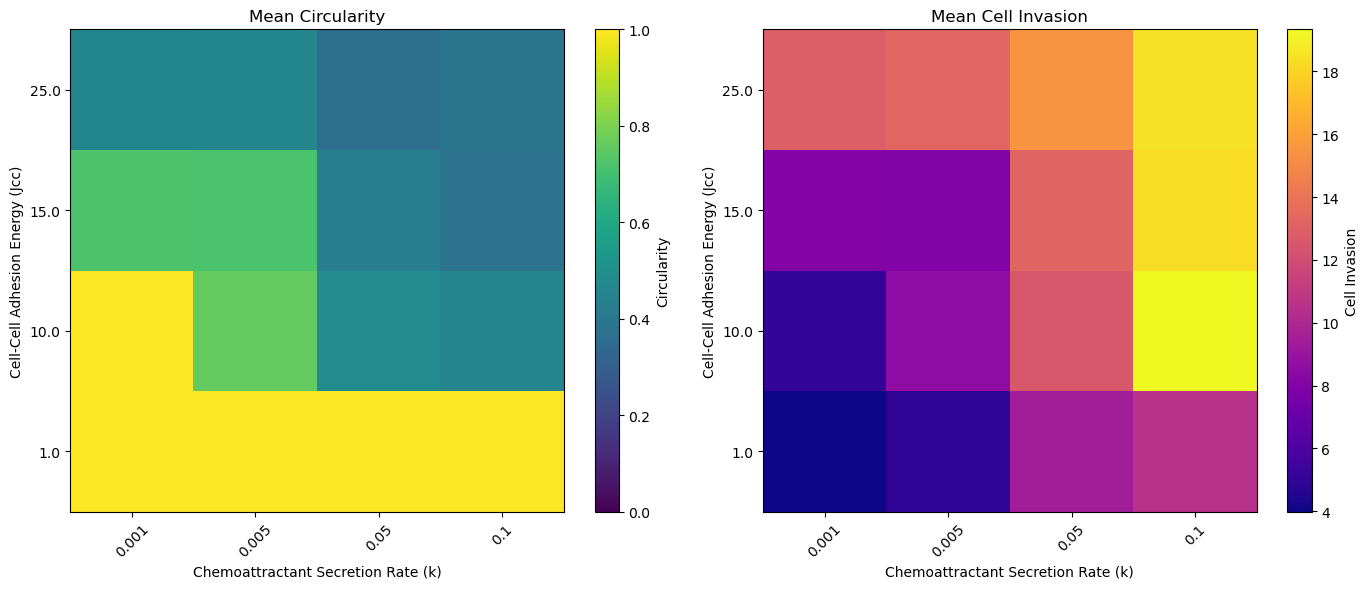

In [93]:
# heatmap for network phenotype with mean circularity and mean cell invasion over each 20 replicates
pivot_circ, pivot_invasion = plot_invasion_circularity_heatmaps(all_net)

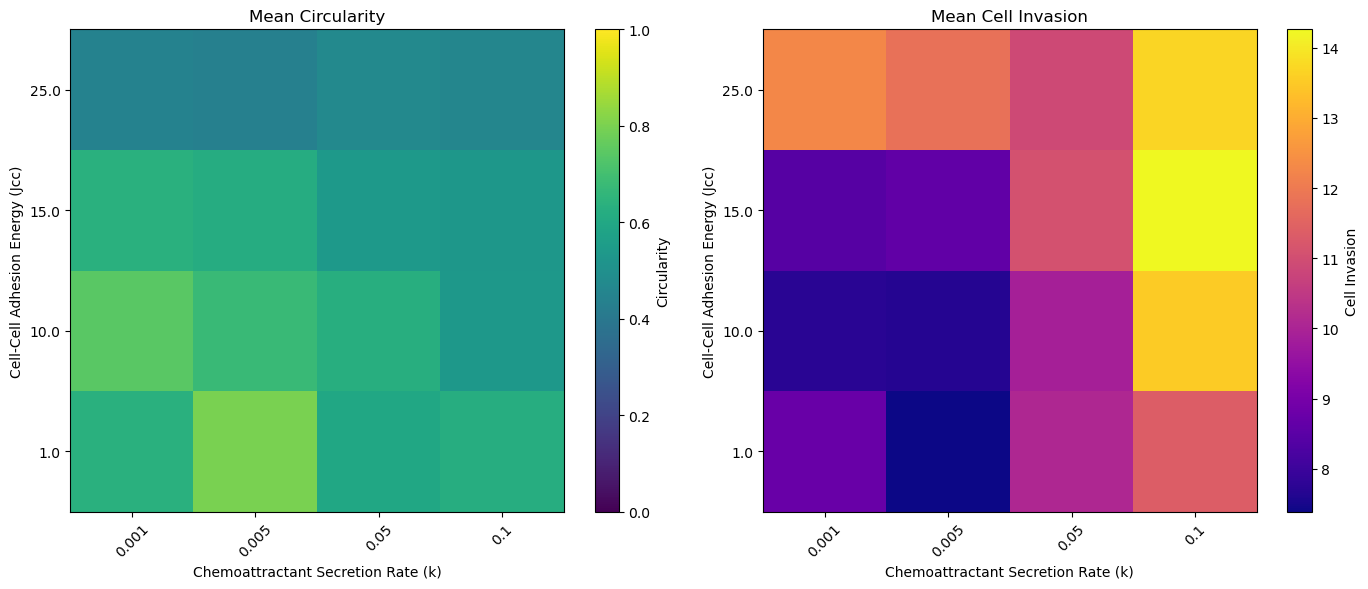

In [94]:
# heatmap for spheriod phenotype with mean circularity and mean cell invasion over each 20 replicates
pivot_circ, pivot_invasion = plot_invasion_circularity_heatmaps(all_sph)

##### Polar trajectories

In [95]:
def plot_polar_trajectories(
    df,
    time_col="mcs",
    x_col="x",
    y_col="y",
    label_col=None,            # e.g., "cell_label" in titles
    normalize_origin=True,
    mode="facet",              # "overlay" | "facet"
    facet_cols=3,
    figsize_overlay=(7, 7),
    figsize_facet=(6, 6),
    color_by_time=False,       # color segments by time gradient
    cmap_name="viridis",
    # --- CLEANING OPTIONS ---
    remove_outliers=True,      # Hampel-like outlier removal in displacement
    outlier_k=5,               # window (points) for median baseline
    outlier_thresh=3.0,        # threshold in MAD units
    resample_to_n=200,         # resample each trajectory to N points (None = skip)
    smooth=True,               # Savitzky–Golay smoothing
    smooth_window=15,          # must be odd and >= 5; adjusted automatically if needed
    smooth_poly=2,             # polynomial order for Savitzky–Golay
    # --- PLOTTING TWEAKS ---
    linewidth=2.0,
    start_marker=dict(color="green", s=30),
    end_marker=dict(color="red", s=30),
    arrow_end=True,            # draw a small arrow at the final segment
):
    """
    Plot CLEAN polar trajectories for all cells in df:
    - optional Hampel outlier removal on step-wise displacements
    - optional uniform-time resampling (cubic) for smooth curves
    - optional Savitzky–Golay smoothing on (x,y)

    Required df columns: ['cell_id', time_col, x_col, y_col]
    """

    # --------- checks ---------
    req = {"cell_id", time_col, x_col, y_col}
    miss = req - set(df.columns)
    if miss:
        raise KeyError(f"Missing required columns: {sorted(miss)}")

    # sort & coerce numeric
    df = df.copy()
    for c in [time_col, x_col, y_col]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["cell_id", time_col, x_col, y_col])
    df = df.sort_values([ "cell_id", time_col ])

    # unique cells
    cell_ids = df["cell_id"].dropna().unique().tolist()
    n_cells = len(cell_ids)
    if n_cells == 0:
        raise ValueError("No valid cell_id found.")

    # colormap (distinct per cell if not color_by_time)
    cmap = get_cmap(cmap_name)
    cell_color = {cid: cmap(i / max(1, n_cells - 1)) for i, cid in enumerate(cell_ids)}

    # ------- helpers -------
    def _hampel_mask(v, k=5, thresh=3.0):
        """Hampel-like mask of outliers (True=keep). v is 1D array."""
        n = len(v)
        if n < 3:
            return np.ones(n, dtype=bool)
        keep = np.ones(n, dtype=bool)
        for i in range(n):
            lo, hi = max(0, i-k), min(n, i+k+1)
            med = np.median(v[lo:hi])
            mad = np.median(np.abs(v[lo:hi] - med)) + 1e-12
            if abs(v[i] - med) > thresh * 1.4826 * mad:
                keep[i] = False
        return keep

    def _resample_uniform(t, x, y, N=200):
        """Resample (x,y) on uniform time grid using cubic interpolation."""
        if len(t) < 4 or N is None or N < 4:
            return t, x, y
        t0, t1 = t.min(), t.max()
        if t1 <= t0:
            return t, x, y
        tu = np.linspace(t0, t1, N)
        # Use pandas interpolate (cubic) with index as time
        s = pd.DataFrame({ "x": x, "y": y }, index=t).sort_index()
        s = s[~s.index.duplicated(keep="first")]
        # If not enough points for cubic, fallback to linear automatically
        method = "cubic" if len(s) >= 4 else "linear"
        s_interp = s.reindex(s.index.union(tu)).sort_index().interpolate(method=method).loc[tu]
        return tu, s_interp["x"].to_numpy(), s_interp["y"].to_numpy()

    def _smooth_xy(x, y, window=15, poly=2):
        """Savitzky–Golay smoothing (applied separately to x and y)."""
        n = len(x)
        if not smooth or n < 5:
            return x, y
        # window must be odd and <= n
        w = min(window if window % 2 == 1 else window+1, n - 1 if (n - 1) % 2 == 1 else n - 2)
        w = max(5, w)  # at least 5
        if w <= poly:
            poly = max(1, min(poly, w - 1))
        try:
            xs = savgol_filter(x, w, poly, mode="interp")
            ys = savgol_filter(y, w, poly, mode="interp")
            return xs, ys
        except Exception:
            # fallback no smoothing
            return x, y

    def _prep_cell(sub):
        """Clean and prepare one cell trajectory; return theta, r, time arrays."""
        sub = sub.copy().sort_values(time_col)
        # drop duplicate times
        sub = sub.loc[~sub[time_col].duplicated(keep="first")]

        # normalize to start at origin for visual clarity
        if normalize_origin:
            sub[x_col] = sub[x_col] - sub[x_col].iloc[0]
            sub[y_col] = sub[y_col] - sub[y_col].iloc[0]

        # Outlier removal on step-wise displacement
        if remove_outliers and len(sub) >= 5:
            dx = sub[x_col].diff().to_numpy()
            dy = sub[y_col].diff().to_numpy()
            disp = np.hypot(dx, dy)
            keep = np.ones(len(sub), dtype=bool)
            keep[1:] = _hampel_mask(disp[1:], k=outlier_k, thresh=outlier_thresh)
            sub = sub.loc[keep]

        # Resample to uniform time (optional)
        t = sub[time_col].to_numpy()
        x = sub[x_col].to_numpy()
        y = sub[y_col].to_numpy()
        t, x, y = _resample_uniform(t, x, y, N=resample_to_n)

        # Smooth (optional)
        x, y = _smooth_xy(x, y, window=smooth_window, poly=smooth_poly)

        # Polar transform
        r = np.hypot(x, y)
        theta = np.arctan2(y, x)
        return theta, r, t

    # --------- plotting ---------
    if mode == "overlay":
        fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=figsize_overlay)
        ax.set_title("Polar Trajectories")
        for cid in cell_ids:
            sub = df[df["cell_id"] == cid]
            if len(sub) < 2: 
                continue
            theta, r, t = _prep_cell(sub)

            if color_by_time and len(t) > 1:
                # color segments by normalized time
                tnorm = (t - t.min()) / (t.max() - t.min() + 1e-12)
                for i in range(1, len(t)):
                    ax.plot(theta[i-1:i+1], r[i-1:i+1], color=cmap(tnorm[i]), linewidth=linewidth)
            else:
                ax.plot(theta, r, color=cell_color[cid], linewidth=linewidth, label=f"Cell {cid}")

            # start & end
            ax.scatter(theta[0], r[0], **start_marker, zorder=5)
            ax.scatter(theta[-1], r[-1], **end_marker, zorder=5)
            if arrow_end and len(theta) >= 2:
                ax.annotate("",
                    xy=(theta[-1], r[-1]),
                    xytext=(theta[-2], r[-2]),
                    arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.8)
                )
        ax.set_rlabel_position(0)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
        plt.tight_layout()
        plt.show()
        return fig, ax

    elif mode == "facet":
        ncols = min(facet_cols, n_cells)
        nrows = int(np.ceil(n_cells / ncols))
        fig_w = figsize_facet[0] * ncols
        fig_h = figsize_facet[1] * nrows
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols,
            subplot_kw={"projection": "polar"},
            figsize=(fig_w, fig_h)
        )
        axes = np.array(axes).reshape(-1)

        for i, cid in enumerate(cell_ids):
            ax = axes[i]
            sub = df[df["cell_id"] == cid]
            if len(sub) < 2:
                ax.set_axis_off()
                continue
            theta, r, t = _prep_cell(sub)

            # draw
            if color_by_time and len(t) > 1:
                tnorm = (t - t.min()) / (t.max() - t.min() + 1e-12)
                for k in range(1, len(t)):
                    ax.plot(theta[k-1:k+1], r[k-1:k+1], color=cmap(tnorm[k]), linewidth=linewidth)
            else:
                ax.plot(theta, r, color=cell_color[cid], linewidth=linewidth)

            ax.scatter(theta[0], r[0], **start_marker, zorder=5)
            ax.scatter(theta[-1], r[-1], **end_marker, zorder=5)
            if arrow_end and len(theta) >= 2:
                ax.annotate("",
                    xy=(theta[-1], r[-1]),
                    xytext=(theta[-2], r[-2]),
                    arrowprops=dict(arrowstyle="->", lw=1.0, alpha=0.8)
                )

            # title
            if label_col and label_col in sub.columns:
                lbl = str(sub[label_col].iloc[0])
                ax.set_title(f"Cell {cid} ({lbl})", fontsize=10, pad=8)
            else:
                ax.set_title(f"Cell {cid}", fontsize=10, pad=8)

            ax.set_rlabel_position(0)
            ax.grid(True, linestyle="--", alpha=0.5)

        # turn off unused
        for j in range(len(cell_ids), len(axes)):
            axes[j].set_axis_off()

        plt.tight_layout()
        plt.show()
        return fig, axes

    else:
        raise ValueError("mode must be 'overlay' or 'facet'")


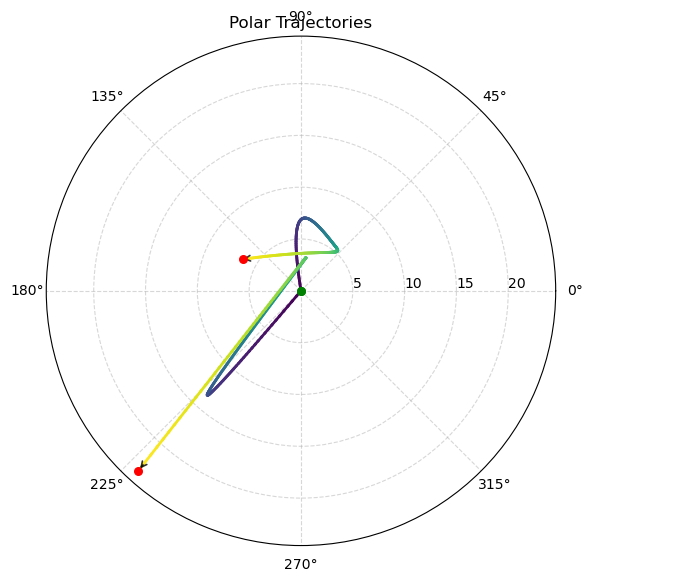

In [96]:
# Clean, overlay all cells with time gradient coloring
plot_polar_trajectories(all_net, mode="overlay", color_by_time=True);

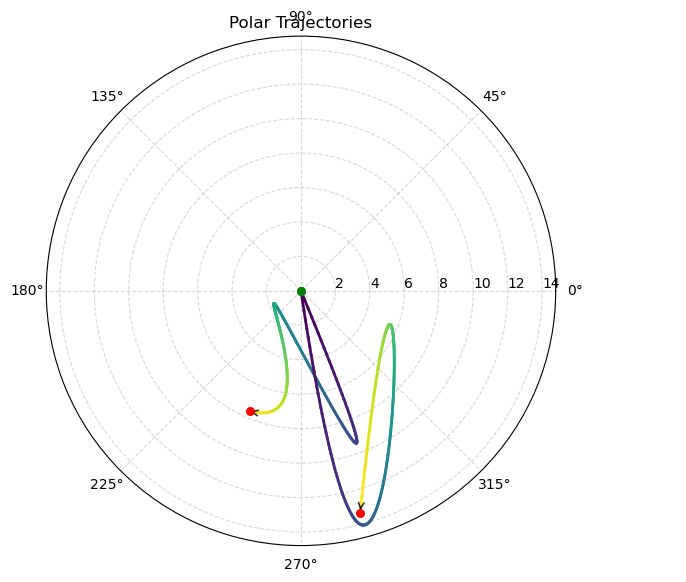

In [97]:
# Clean, overlay all cells with time gradient coloring
plot_polar_trajectories(all_sph, mode="overlay", color_by_time=True);